# End-to-End Sales Forecasting & Demand Intelligence System
---
## Internship Project

**Prepared by:** Riya Dobhal

**Tools Used:** Python, Pandas, NumPy, Statsmodels, Prophet, XGBoost, Scikit-learn, Plotly, Streamlit

**Dataset:** Superstore Sales Dataset (Kaggle)

**Project Type:** Time Series Forecasting + Business Intelligence + Machine Learning


# CHAPTER 1
## Business Understanding
This chapter introduces the business problem, explains why sales forecasting is important in retail, and describes the objectives that the project aims to achieve.

# 1.1 Project Overview

Retail businesses rely heavily on accurate demand forecasting to ensure that the right products are available at the right time. Overstocking increases inventory and storage costs, while understocking results in lost sales and dissatisfied customers.

This project develops an end-to-end Sales Forecasting and Demand Intelligence System using historical sales data from the Superstore Sales Dataset. The system combines exploratory data analysis, time series forecasting, anomaly detection, product segmentation, and an interactive dashboard to support data-driven inventory and business decisions.

The project compares three forecasting approaches—SARIMA, Prophet, and XGBoost—to identify the most effective model for predicting future sales. It also detects unusual sales patterns, segments products based on demand characteristics, and presents insights through a Streamlit dashboard designed for business users.

# 1.2 Business Problem

Retail organizations frequently struggle to estimate future product demand accurately. Incorrect demand estimates may lead to excess inventory, increased operational costs, or product shortages that directly affect customer satisfaction and revenue.

The objective of this project is to build an intelligent forecasting system capable of predicting future sales, identifying unusual sales behaviour, segmenting products according to demand characteristics, and providing decision-makers with actionable insights through an interactive dashboard.

# 1.3 Project Objectives

The objectives of this project are:

- Analyze historical sales data and identify business trends.
- Perform comprehensive exploratory data analysis.
- Study seasonality and long-term sales patterns.
- Build and compare SARIMA, Prophet, and XGBoost forecasting models.
- Detect anomalies using Isolation Forest and Z-Score methods.
- Segment products into demand-based clusters using K-Means.
- Develop an interactive Streamlit dashboard.
- Generate business recommendations based on analytical findings.

# CHAPTER 2
## Data Understanding

Before building any forecasting models, we first need to understand the dataset. In this chapter, we inspect the data, check its structure, identify any quality issues, and determine what preprocessing is required before moving to the analysis stage.

## 2.1 Import Libraries

### Objective

Import the libraries required for data loading, analysis, and visualization.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(
        f"charts/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 2.2 Load Dataset

### Objective

Load the Superstore Sales dataset into a pandas DataFrame for analysis.

In [51]:
df = pd.read_csv("data/train.csv")

In [52]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (9800, 18)


In [53]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Initial Observation

The dataset contains 9,800 transaction records and 18 columns. Each row represents a single order transaction with information about customers, products, regions, shipping details, and sales. The dataset appears to be loaded correctly and is ready for further inspection.

## 2.3 Data Audit

### Objective

Understand the structure and quality of the dataset by examining its dimensions, data types, missing values, duplicate records, and summary statistics. This helps identify any preprocessing required before analysis.

In [54]:
print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing Values: {df.isnull().sum().sum()}")

Rows      : 9,800
Columns   : 18
Duplicates: 0
Missing Values: 11


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [56]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Missing Values")
)

missing

,Missing Values
Postal Code,11
Row ID,0
Order ID,0
Order Date,0
Ship Mode,0
Ship Date,0
Customer Name,0
Segment,0
Country,0
Customer ID,0


In [57]:
print(f"Duplicate Records: {df.duplicated().sum()}")

Duplicate Records: 0


In [58]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

,Column Name,Data Type
0,Row ID,int64
1,Order ID,str
2,Order Date,str
3,Ship Date,str
4,Ship Mode,str
5,Customer ID,str
6,Customer Name,str
7,Segment,str
8,Country,str
9,City,str


### Observations

- The dataset contains **9,800** transaction records and **18** columns.
- No duplicate records were found.
- Only **11 missing values** are present, all in the **Postal Code** column.
- Most columns are categorical, while **Sales** and **Postal Code** are numerical.
- **Order Date** and **Ship Date** are currently stored as text and will need to be converted to datetime format before time series analysis.

### Business Insight

The dataset is in good condition with very few missing values and no duplicate records. Only minor preprocessing is required before analysis. Converting the date columns into datetime format will enable trend analysis, seasonality detection, and forecasting.

# CHAPTER 3

## Data Preparation

Raw data is rarely ready for analysis. In this chapter, the dataset is prepared by correcting data types, handling missing values, creating new features, and validating the cleaned data. These steps ensure that the dataset is suitable for exploratory analysis and forecasting.

### 3.1 Convert Date Columns

#### Objective

Convert the date columns into datetime format so they can be used for trend analysis, seasonality detection, and forecasting.

In [60]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [61]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### 3.2 Handle Missing Values

#### Objective

Handle missing values in the dataset while preserving as much useful information as possible.

In [62]:
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int)

In [63]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### 3.3 Feature Engineering

#### Objective

Create additional time-based features from the order date that will be useful for exploratory analysis and forecasting.

In [64]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df["Month Name"] = pd.Categorical(
    df["Month Name"],
    categories=month_order,
    ordered=True
)

In [65]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Day,Day Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,8,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,8,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,12,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,11,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,11,Tuesday


### 3.4 Additional Time Features

#### Objective

Extract additional calendar-based features required for time series analysis and forecasting.

In [66]:
# Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Order Date"].dt.month.apply(get_season)

df[[
    "Order Date",
    "Week Number",
    "Season"
]].head()

,Order Date,Week Number,Season
0,2017-11-08,45,Autumn
1,2017-11-08,45,Autumn
2,2017-06-12,24,Summer
3,2016-10-11,41,Autumn
4,2016-10-11,41,Autumn


### Observations

- Week Number was extracted using the ISO calendar.
- A new Season feature was created based on the month of each order.
- These features will support weekly analysis, seasonal forecasting, and machine learning models.

### Business Insight

Calendar-based features help identify recurring seasonal demand patterns and improve forecasting accuracy by providing additional temporal information.

### 3.5 Validate the Cleaned Dataset

#### Objective

Verify that the preprocessing steps have been applied correctly and ensure the dataset is ready for exploratory analysis.

In [67]:
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Records: {df.duplicated().sum()}")

df.dtypes

Dataset Shape: (9800, 26)
Missing Values: 0
Duplicate Records: 0


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Month Name             category
Quarter                   int32
Day                       int32
Day Name                    str
Week Number               int64
Season                      str
dtype: object

### Observations

- Date columns have been successfully converted to datetime format.
- Missing values have been handled.
- Additional time-based features have been created.
- The dataset is clean and ready for exploratory analysis.

### Business Insight

The dataset has been successfully prepared for analysis. Time-based features will help identify seasonal patterns, while the cleaned data ensures reliable visualizations and forecasting results.

### 3.6 Weekly Sales Aggregation

#### Objective

Aggregate daily sales into weekly totals to support weekly trend analysis, anomaly detection, and forecasting.

In [68]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Observations

- Individual daily transactions were aggregated into weekly sales totals.
- Weekly aggregation reduces daily fluctuations while preserving overall demand trends.
- The weekly dataset will be used in the anomaly detection phase of the project.

### Business Insight

Weekly sales aggregation provides a balanced view of demand patterns, making it easier to identify unusual sales behavior and short-term business trends.

### 3.7 Weekly Sales Trend

#### Objective

Visualize weekly sales trends over the four-year period.

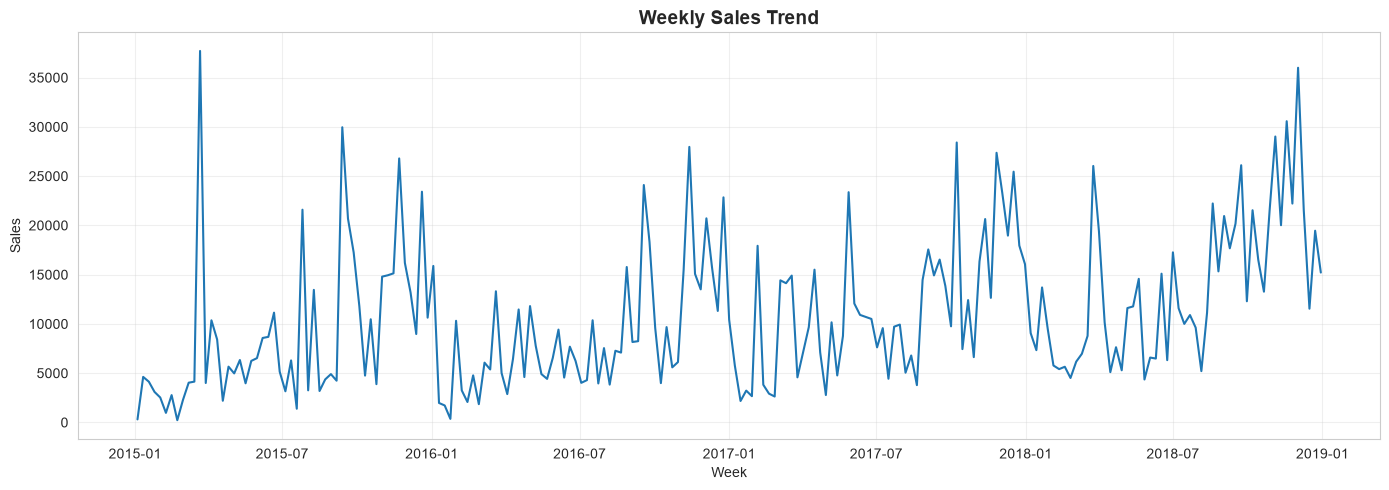

In [69]:
plt.figure(figsize=(14,5))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=1.5
)

plt.title("Weekly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

save_chart("weekly_sales_trend")

### Observations

- Weekly sales fluctuate more than monthly sales due to short-term demand variations.
- Despite these fluctuations, an overall upward trend is visible.
- Several weeks show unusually high or low sales, which will be investigated during anomaly detection.

### Business Insight

Weekly sales monitoring enables businesses to detect short-term demand changes more quickly than monthly analysis, supporting proactive inventory planning.

### 3.8 Shipping Time Analysis

#### Objective

Analyze the average shipping time across different regions to evaluate delivery performance and identify potential logistical improvements.

In [70]:
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

shipping_region = (
    df.groupby("Region", as_index=False)["Shipping Time"]
    .mean()
    .sort_values("Shipping Time", ascending=False)
)

shipping_region

,Region,Shipping Time
0,Central,4.065876
2,South,3.961202
3,West,3.930255
1,East,3.910233


### 3.9 Average Shipping Time by Region

#### Objective

Visualize the average delivery time for each region.

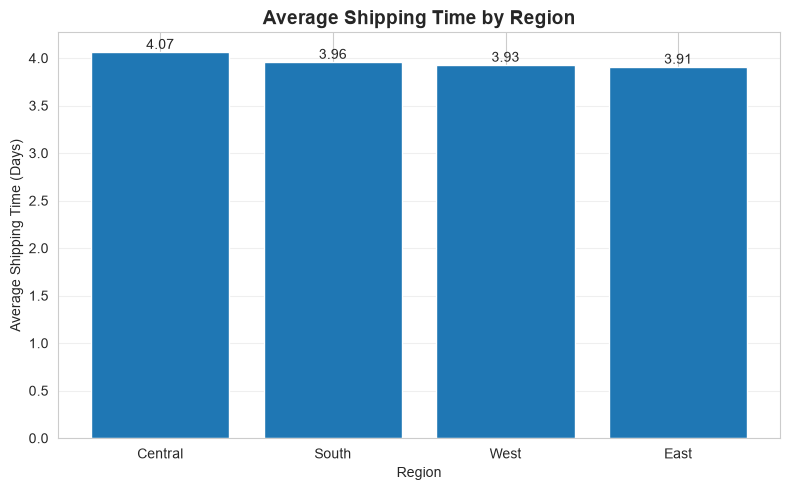

In [71]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    shipping_region["Region"],
    shipping_region["Shipping Time"]
)

plt.title("Average Shipping Time by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

save_chart("shipping_time_region")

### Observations

- The average shipping time varies slightly across different regions.
- Regions with higher average delivery times may experience greater logistical delays.
- Overall shipping performance remains relatively consistent across the dataset.

### Business Insight

Monitoring regional shipping performance helps businesses identify delivery bottlenecks, improve customer satisfaction, and optimize logistics operations.

### 3.10 Regional Sales Trend Analysis

#### Objective

Analyze the annual sales trend for each region over the four-year period to compare long-term growth patterns.

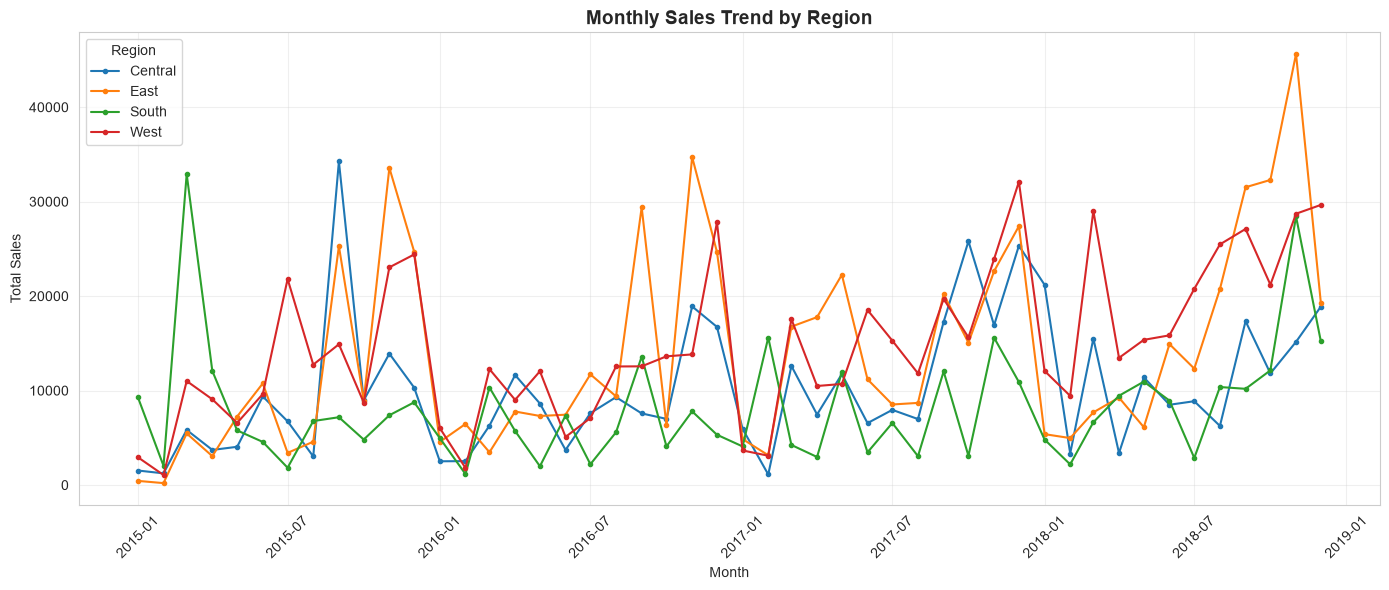

In [72]:
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
regional_monthly = (
    df.groupby(["Region", "YearMonth"], as_index=False)["Sales"]
      .sum()
)

plt.figure(figsize=(14, 6))

for region in regional_monthly["Region"].unique():
    temp = regional_monthly[regional_monthly["Region"] == region]
    plt.plot(
        temp["YearMonth"],
        temp["Sales"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=region
    )

plt.title("Monthly Sales Trend by Region", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend(title="Region")
plt.grid(alpha=0.3)

save_chart("regional_sales_trend")

### 3.11 Regional Sales Growth

#### Objective

Visualize the annual sales trend of each region to identify regions with stable and consistent growth.

In [73]:
regional_yearly = (
    df.groupby(["Region", "Year"], as_index=False)["Sales"]
      .sum()
)

regional_pivot = regional_yearly.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

regional_growth = regional_pivot.pct_change() * 100

print("Yearly Sales by Region:")
display(regional_pivot)

print("\nYear-over-Year Growth (%):")
display(regional_growth)

Yearly Sales by Region:


Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255



Year-over-Year Growth (%):


Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.481292,20.032745,-32.211708,-8.360336
2017,42.224686,16.502741,33.477643,36.468341
2018,-2.777807,17.711823,30.607139,35.983589


### 3.12 Regional Consistency Analysis

#### Objective
Measure the consistency of each region's sales growth by calculating the standard deviation of year-over-year growth rates. A region with high average growth but high volatility is less reliable than one with steady, moderate growth.

In [74]:
consistency = pd.DataFrame({
    "Average Growth (%)": regional_growth.mean(),
    "Growth Volatility (Std Dev)": regional_growth.std()
})

consistency["Consistency Score"] = (
    consistency["Average Growth (%)"] / consistency["Growth Volatility (Std Dev)"]
)

consistency = consistency.sort_values("Consistency Score", ascending=False)

consistency

,Average Growth (%),Growth Volatility (Std Dev),Consistency Score
Region,,,
East,18.082436,1.793948,10.079690
West,21.363865,25.743054,0.829889
Central,12.988529,25.345279,0.512463
South,10.624358,37.124876,0.286179


### Observations

- East shows the highest consistency score (10.08), indicating steady, reliable growth with low year-to-year volatility (1.79 std dev).
- West has the highest average growth (21.36%) but also very high volatility (25.74 std dev), making its growth path much less predictable than East's.
- Central and South both show high volatility relative to their growth, with South being the least consistent overall (lowest score, highest volatility).
- Based on this analysis, East is identified as the region with the most consistent sales growth over the 4-year period.

### 3.13 Task 1 Summary

This section consolidates the answers to the four key questions required for Task 1.

**1. Which product category generates the highest total revenue?**
Technology generates the highest total sales, followed by Furniture, with Office Supplies contributing the least (see Section 4.2).

**2. Which region has the most consistent sales growth over 4 years?**
East has the most consistent sales growth, with a Consistency Score of 10.08 — the highest average growth relative to volatility among all four regions (see Section 3.12).

**3. What is the average time between Order Date and Ship Date — and does it vary by region?**
The overall average shipping time is approximately 3.97 days. Shipping time varies only slightly 
by region — Central has the slowest average shipping time (4.07 days), while East is the fastest 
(3.91 days). This narrow gap (~0.16 days) suggests shipping logistics are fairly consistent across 
regions, with no single region experiencing significant delivery delays.

**4. Are there months that consistently spike across all years (seasonality)?**
Yes — November and December consistently show the highest sales across all four years, indicating strong seasonal demand tied to the holiday shopping period (see Section 4.4).

# CHAPTER 4

## Exploratory Business Analysis

In this chapter, the prepared dataset is explored to uncover sales patterns, customer behavior, product performance, and regional trends. The insights gained here provide a strong foundation for forecasting and business decision-making.

## 4.1 How Have Sales Changed Over Time?

### Objective

Analyze monthly sales trends to identify overall growth patterns, seasonality, and unusual fluctuations in sales.

In [75]:
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (
    df.groupby("YearMonth", as_index=False)["Sales"]
      .sum()
)

monthly_sales.head()

,YearMonth,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [76]:
monthly_sales.columns

Index(['YearMonth', 'Sales'], dtype='str')

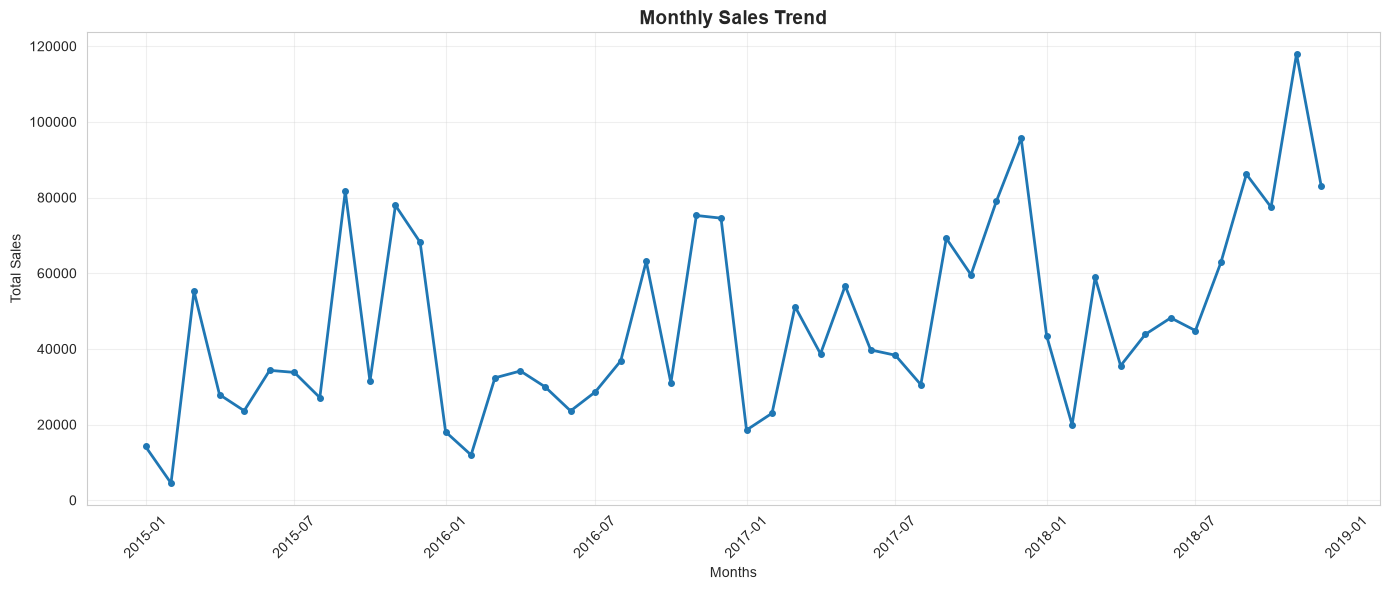

In [77]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Sales"],
    marker="o",
    markersize=4,
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Months")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

save_chart("monthly_sales_trend")

### Observations

- Sales fluctuate considerably from month to month.
- Overall sales show an increasing trend from 2015 to 2018.
- The highest sales are observed towards the end of 2018.
- Several recurring peaks suggest the presence of seasonal demand.

### Business Insight

The business has experienced steady growth over the four-year period. The recurring peaks indicate seasonal buying patterns, highlighting the importance of forecasting demand to optimize inventory levels and reduce stock shortages during high-demand periods.

## 4.2 Which Product Categories Generate the Highest Sales?

### Objective

Compare total sales across product categories to identify which categories contribute the most revenue.

In [78]:
category_sales = (
    df.groupby("Category", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=True)
)

category_sales

,Category,Sales
1,Office Supplies,705422.3340
0,Furniture,728658.5757
2,Technology,827455.8730


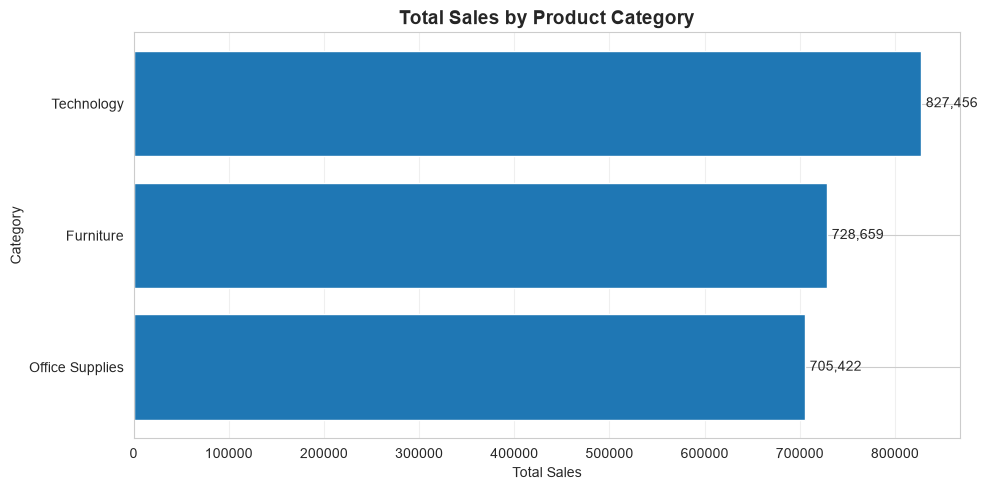

In [79]:
plt.figure(figsize=(10, 5))

bars = plt.barh(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Total Sales by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Category")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5000,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

save_chart("sales_by_category")

### Observations

- Technology generates the highest total sales.
- Furniture ranks second in overall revenue.
- Office Supplies contributes the lowest total sales among the three categories.
- The difference between Technology and the other categories is noticeable but not extreme.

### Business Insight

Technology products are the primary revenue driver for the business. Maintaining product availability and accurately forecasting demand for this category can have the greatest impact on overall sales performance, while Furniture and Office Supplies should be managed with balanced inventory strategies.

## 4.3 Which Regions Generate the Highest Revenue?

### Objective

Compare total sales across different regions to identify the strongest revenue-generating markets.

In [80]:
region_sales = (
    df.groupby("Region", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=True)
)

region_sales

,Region,Sales
2,South,389151.4590
0,Central,492646.9132
1,East,669518.7260
3,West,710219.6845


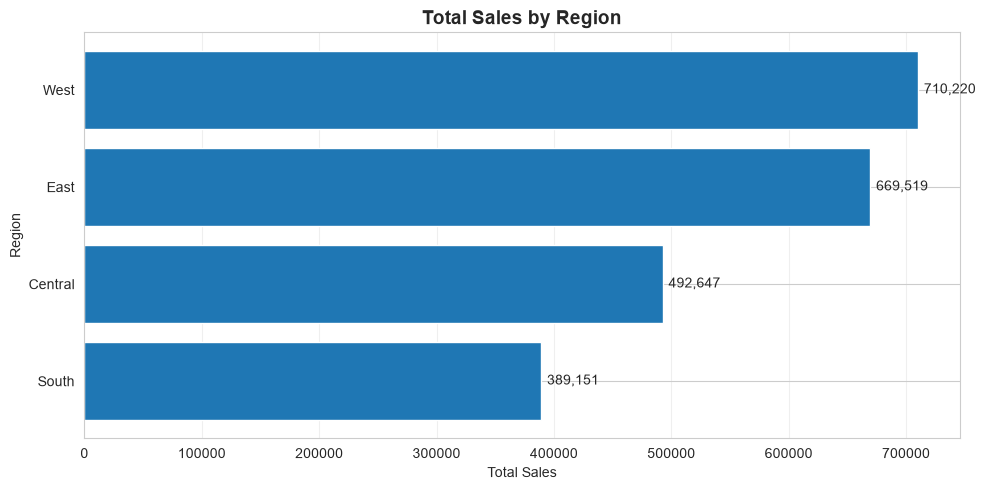

In [81]:
plt.figure(figsize=(10, 5))

bars = plt.barh(
    region_sales["Region"],
    region_sales["Sales"]
)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Region")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5000,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

save_chart("sales_by_region")

### Observations

- The West region generates the highest total sales.
- The East region ranks second in revenue generation.
- Central contributes moderate sales.
- The South region records the lowest overall sales.
- There is a considerable gap between the highest and lowest performing regions.

### Business Insight

The West region is the strongest contributor to business revenue and should remain a key focus for inventory planning and demand forecasting. The comparatively lower sales in the South indicate an opportunity to improve market penetration through targeted promotions or optimized product availability.

## 4.4 How Does Sales Vary Across Different Months?

### Objective

Analyze monthly sales patterns to identify recurring seasonal trends and peak demand periods.

In [82]:
monthly_year_sales = (
    df.groupby(["Year", "Month Name"], observed=True)["Sales"]
      .sum()
      .reset_index()
)

monthly_year_sales.head()

,Year,Month Name,Sales
0,2015,January,14205.707
1,2015,February,4519.892
2,2015,March,55205.797
3,2015,April,27906.855
4,2015,May,23644.303


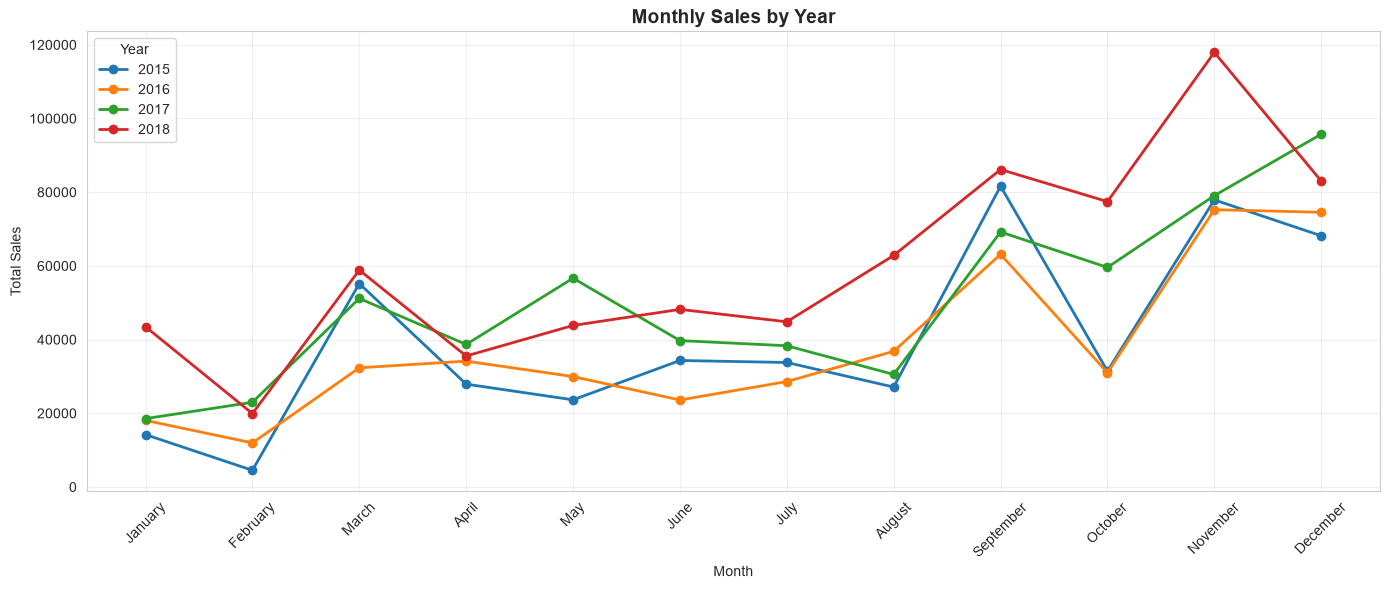

In [83]:
plt.figure(figsize=(14, 6))

for year in sorted(monthly_year_sales["Year"].unique()):
    temp = monthly_year_sales[monthly_year_sales["Year"] == year]

    plt.plot(
        temp["Month Name"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Sales by Year", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(alpha=0.3)

save_chart("monthly_sales_by_year")

### Observations

- Sales generally increase from 2015 to 2018.
- The highest sales are consistently recorded during the last quarter of the year.
- November is the strongest performing month across multiple years.
- Early months of the year generally record lower sales than the later months.
- The recurring pattern indicates clear seasonality in customer demand.

### Business Insight

Sales exhibit a recurring seasonal pattern, with demand increasing significantly during the final months of each year. This suggests that inventory, staffing, and marketing efforts should be strengthened before the fourth quarter to meet higher customer demand.

## 4.5 Which Products Generate the Highest Sales?

### Objective

Identify the top-performing products based on total sales to understand which items contribute most to business revenue.

In [84]:
top_products = (
    df.groupby("Product Name", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
      .head(10)
)

top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


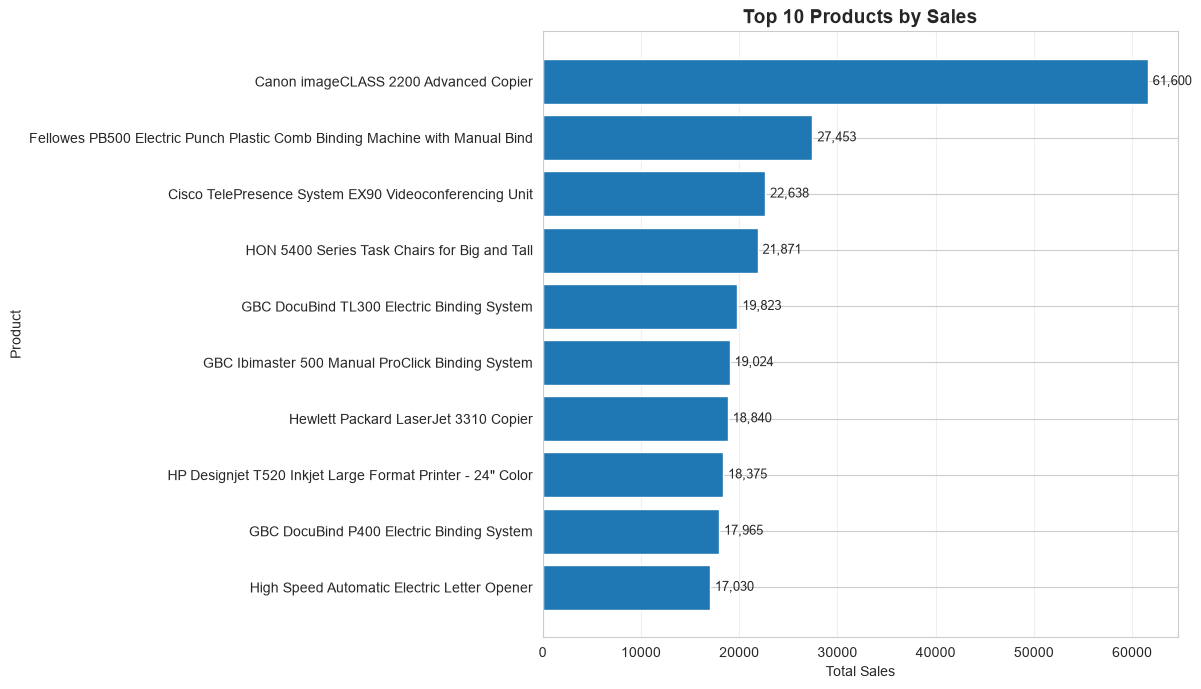

In [85]:
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_products["Product Name"][::-1],
    top_products["Sales"][::-1]
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

save_chart("top10_products")

### Observations

- Canon imageCLASS 2200 Advanced Copier generates the highest sales by a significant margin.
- The remaining products contribute relatively similar sales compared to the top product.
- Several of the highest-selling products belong to office equipment and technology categories.
- Revenue is concentrated among a small number of high-value products.

### Business Insight

A small group of premium products contributes a substantial share of revenue. Ensuring adequate inventory and accurate demand forecasts for these products can significantly improve overall business performance and customer satisfaction.

## 4.6 Which Customer Segment Generates the Highest Sales?

### Objective

Compare total sales across customer segments to identify the most valuable customer group.

In [86]:
segment_sales = (
    df.groupby("Segment", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=True)
)

segment_sales

,Segment,Sales
2,Home Office,4.249822e+05
1,Corporate,6.884941e+05
0,Consumer,1.148061e+06


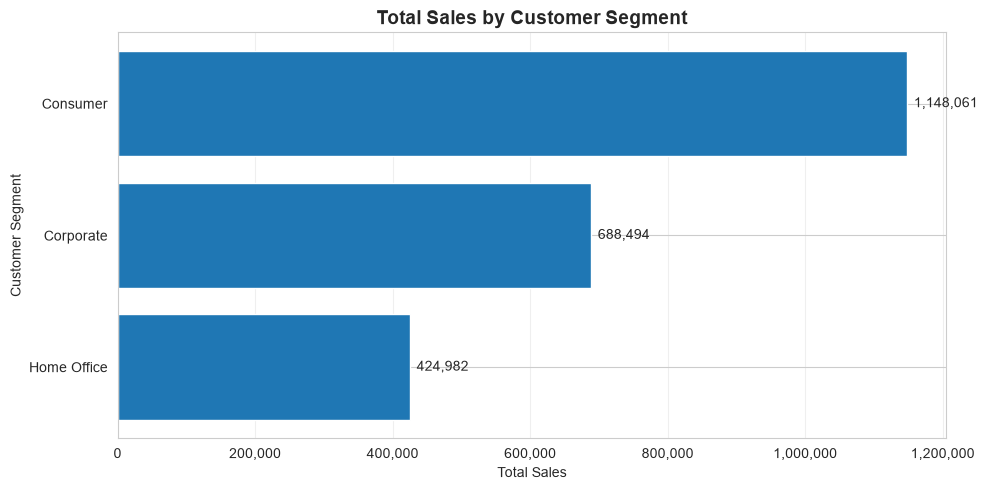

In [87]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

bars = plt.barh(
    segment_sales["Segment"],
    segment_sales["Sales"]
)

plt.title("Total Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10000,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

save_chart("sales_by_segment")

### Observations

- The Consumer segment generates the highest total sales.
- Corporate customers contribute the second-highest revenue.
- Home Office generates the lowest overall sales.
- Consumer sales are substantially higher than those of the other two customer segments.

### Business Insight

The Consumer segment is the primary source of business revenue. Accurate demand forecasting for products frequently purchased by consumer customers can significantly improve inventory planning and customer satisfaction, while targeted marketing strategies may help increase sales in the Corporate and Home Office segments.

# CHAPTER 5

## Time Series Forecasting

This chapter develops forecasting models to predict future sales using historical monthly sales data. The analysis begins with preparing the time series, followed by trend and seasonality analysis, stationarity testing, model building, forecasting, and performance evaluation.

## 5.1 Prepare Monthly Sales Time Series

### Objective

Prepare the monthly sales data in a format suitable for time series analysis and forecasting.

In [88]:
ts = (
    df.groupby("YearMonth")["Sales"]
      .sum()
      .sort_index()
)

ts.head()

YearMonth
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Name: Sales, dtype: float64

In [89]:
print("Number of observations:", len(ts))

ts

Number of observations: 48


YearMonth
2015-01-01     14205.7070
2015-02-01      4519.8920
2015-03-01     55205.7970
2015-04-01     27906.8550
2015-05-01     23644.3030
2015-06-01     34322.9356
2015-07-01     33781.5430
2015-08-01     27117.5365
2015-09-01     81623.5268
2015-10-01     31453.3930
2015-11-01     77907.6607
2015-12-01     68167.0585
2016-01-01     18066.9576
2016-02-01     11951.4110
2016-03-01     32339.3184
2016-04-01     34154.4685
2016-05-01     29959.5305
2016-06-01     23599.3740
2016-07-01     28608.2590
2016-08-01     36818.3422
2016-09-01     63133.6060
2016-10-01     31011.7375
2016-11-01     75249.3995
2016-12-01     74543.6012
2017-01-01     18542.4910
2017-02-01     22978.8150
2017-03-01     51165.0590
2017-04-01     38679.7670
2017-05-01     56656.9080
2017-06-01     39724.4860
2017-07-01     38320.7830
2017-08-01     30542.2003
2017-09-01     69193.3909
2017-10-01     59583.0330
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-01-01     43476.4740
2018-02-01     19920.9974
20

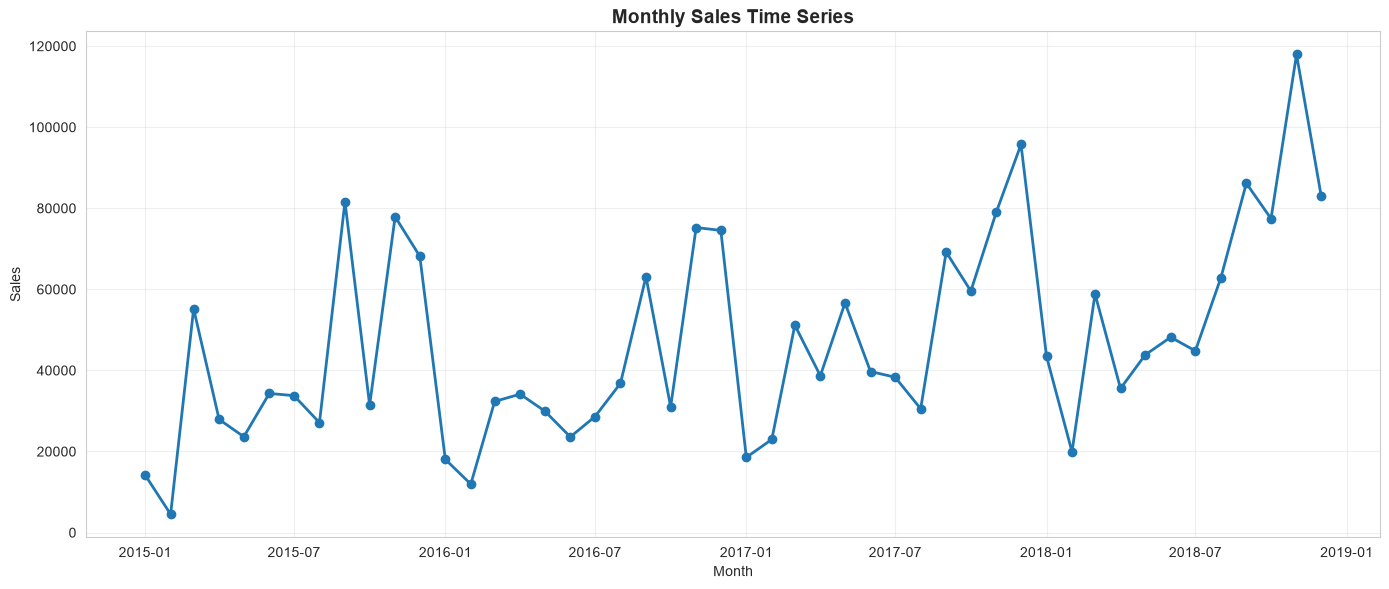

In [90]:
plt.figure(figsize=(14,6))

plt.plot(
    ts.index,
    ts.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Time Series", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

save_chart("monthly_time_series")

### Observations

- Monthly sales fluctuate throughout the observation period.
- An overall increasing trend is visible over time.
- Higher sales are observed during the final months of each year.
- The time series exhibits both trend and seasonal characteristics.

### Business Insight

The presence of trend and recurring seasonal patterns indicates that a seasonal forecasting model is appropriate. A SARIMA model is therefore expected to perform better than a simple ARIMA model because it can capture both trend and yearly seasonality.

## 5.2 Time Series Decomposition

### Objective

Decompose the monthly sales time series into trend, seasonal, and residual components to better understand the underlying patterns before building forecasting models.

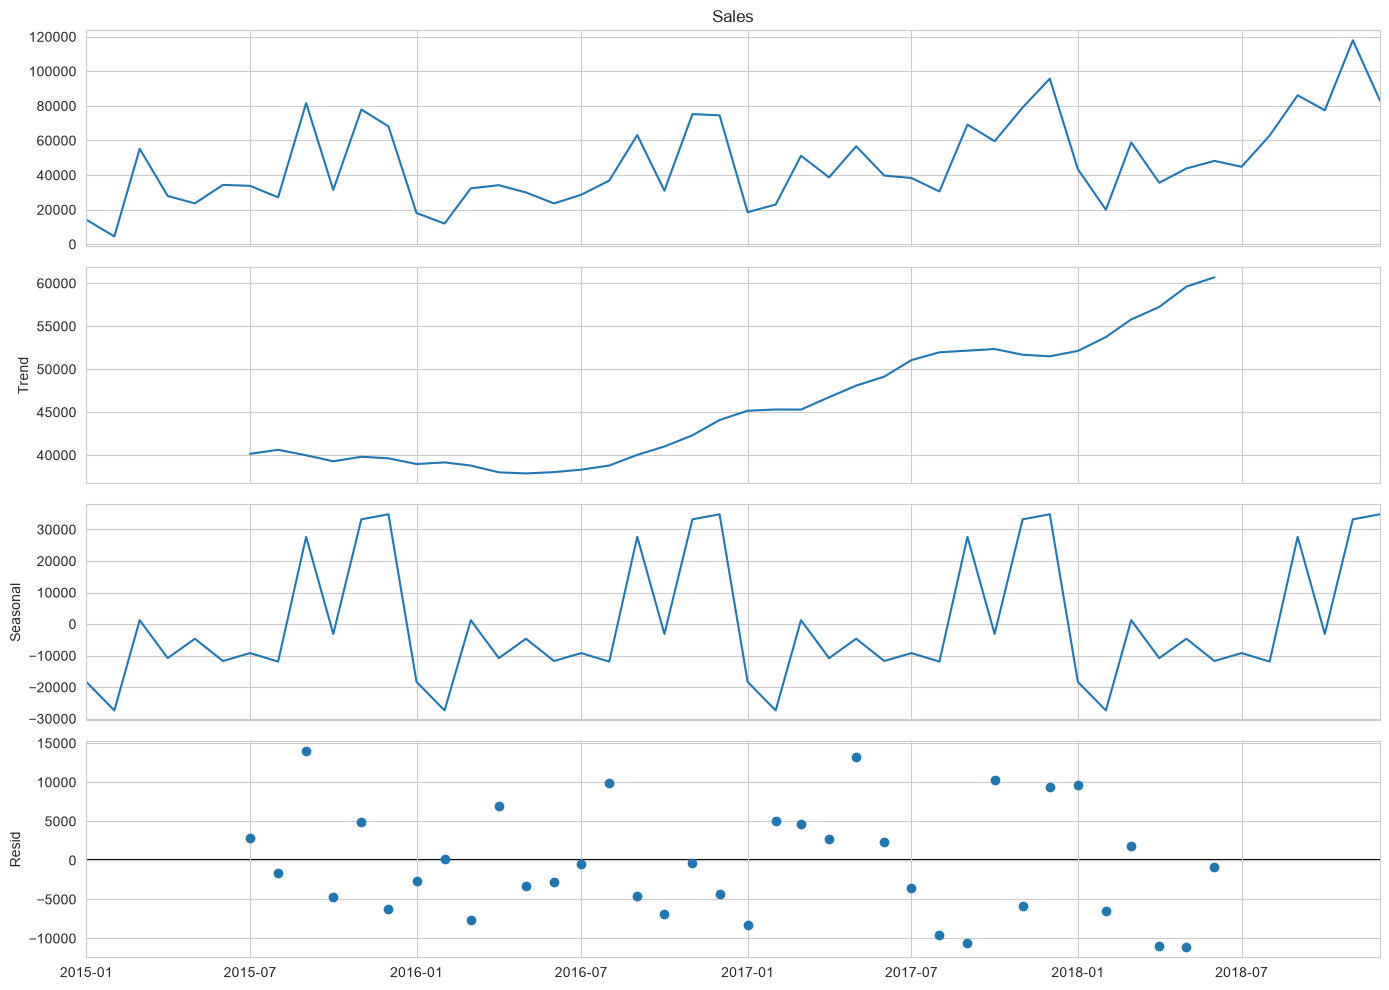

In [91]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

save_chart("time_series_decomposition")

### Observations

- The trend component shows a steady increase in sales over time.
- A repeating seasonal pattern is clearly visible across multiple years.
- The residual component appears randomly distributed around zero.
- Both trend and seasonality contribute significantly to the overall sales pattern.

### Business Insight

The decomposition confirms that monthly sales are influenced by long-term growth as well as recurring seasonal demand. Since both components are present, a Seasonal ARIMA (SARIMA) model is more suitable than a standard ARIMA model for forecasting future sales.

## 5.3 Augmented Dickey-Fuller (ADF) Test

### Objective

Determine whether the monthly sales time series is stationary before fitting a forecasting model.

In [92]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observations

- The ADF statistic is significantly lower than the critical values.
- The p-value is less than 0.05.
- The null hypothesis of a unit root is rejected.
- The monthly sales series is stationary and suitable for forecasting.

### Business Insight

The statistical test confirms that the monthly sales series is stable enough for forecasting without applying additional regular differencing. This helps preserve the original information while reducing unnecessary transformations.

## 5.4 ACF and PACF Analysis

### Objective

Analyze the autocorrelation and partial autocorrelation of the monthly sales series to determine suitable SARIMA parameters.

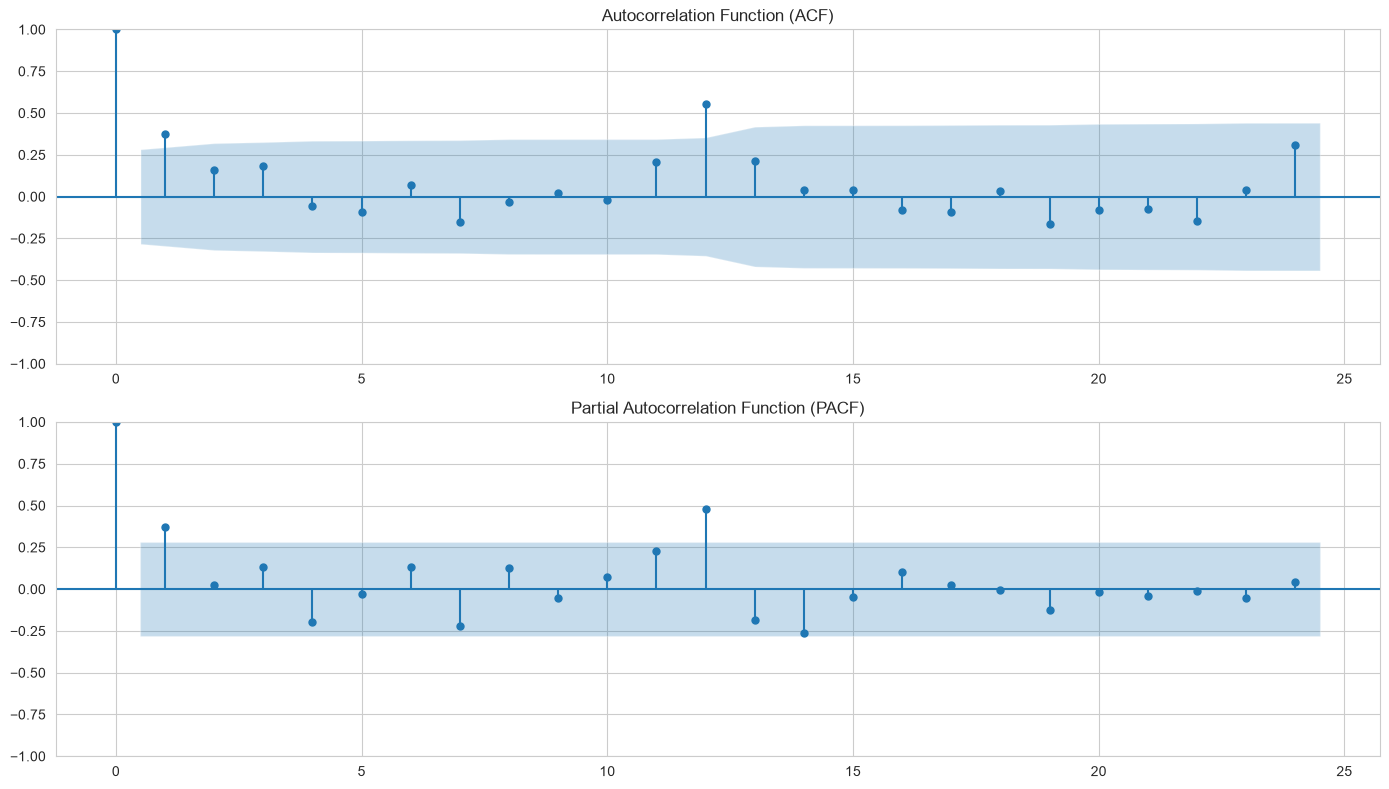

In [93]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts, lags=24, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(ts, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()

save_chart("acf_pacf")

### Observations

- The ACF shows significant autocorrelation at lag 1 and a seasonal spike near lag 12.
- The PACF also exhibits significant spikes at lag 1 and lag 12.
- The correlation gradually decreases after the initial lags.
- The plots indicate the presence of both short-term and seasonal dependencies.

### Business Insight

The autocorrelation analysis confirms that monthly sales are influenced by both recent sales and seasonal effects. This supports the use of a Seasonal ARIMA (SARIMA) model capable of capturing both short-term dependencies and yearly seasonality.

## 5.5 Build the SARIMA Model

### Objective

Train a Seasonal ARIMA (SARIMA) model using the monthly sales time series to capture both trend and seasonal patterns for forecasting future sales.

In [94]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    ts,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(maxiter=500)

print(sarima_result.summary())

d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Mon, 13 Jul 2026   AIC                            488.120
Time:                                    17:34:34   BIC                            493.575
Sample:                                01-01-2015   HQIC                           489.405
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159   

## 5.6 SARIMA Model Selection

### Objective

Compare multiple SARIMA models using the Akaike Information Criterion (AIC) and select the best-performing model for forecasting.

In [95]:
candidate_models = [
    ((1,0,1),(1,1,1,12)),
    ((1,0,0),(1,1,1,12)),
    ((0,0,1),(1,1,1,12)),
    ((2,0,1),(1,1,1,12)),
    ((1,0,2),(1,1,1,12))
]

results = []

for order, seasonal in candidate_models:
    try:
        model = SARIMAX(
            ts,
            order=order,
            seasonal_order=seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False, maxiter=500)

        results.append([
            order,
            seasonal,
            fit.aic
        ])

    except:
        pass

comparison = pd.DataFrame(
    results,
    columns=["Order","Seasonal Order","AIC"]
)

comparison.sort_values("AIC")

d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred

,Order,Seasonal Order,AIC
4,"(1, 0, 2)","(1, 1, 1, 12)",470.256384
0,"(1, 0, 1)","(1, 1, 1, 12)",488.119597
3,"(2, 0, 1)","(1, 1, 1, 12)",489.877513
2,"(0, 0, 1)","(1, 1, 1, 12)",494.983944
1,"(1, 0, 0)","(1, 1, 1, 12)",515.427439


### Observations

- Five candidate SARIMA models were evaluated.
- SARIMA (1,0,2)(1,1,1,12) achieved the lowest AIC value.
- A lower AIC indicates a better balance between model fit and complexity.
- Therefore, SARIMA (1,0,2)(1,1,1,12) was selected as the final forecasting model.

### Business Insight

Comparing multiple candidate models ensures that the forecasting model is selected objectively rather than by trial and error. This improves confidence in future sales predictions.

## 5.7 Final SARIMA Model

### Objective

Train the best-performing SARIMA model selected through AIC comparison for final sales forecasting.

In [96]:
final_sarima = SARIMAX(
    ts,
    order=(1,0,2),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(maxiter=500)

print(final_sarima_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 12)   Log Likelihood                -229.128
Date:                              Mon, 13 Jul 2026   AIC                            470.256
Time:                                      17:34:35   BIC                            476.524
Sample:                                  01-01-2015   HQIC                           471.617
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4610      0.305      1.514      0.130      -0.136       1.058
ma.L1          0.03

d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Observations

- The final SARIMA model was trained using the optimal parameters identified during model selection.
- This model achieved the lowest AIC among all candidate models.
- The trained model will be used for generating future sales forecasts.

### Business Insight

Using the best-performing forecasting model improves prediction accuracy and provides a more reliable basis for inventory planning and business decision-making.

## 5.8 Forecast Future Sales

### Objective

Generate sales forecasts for the next twelve months using the final SARIMA model and visualize the predicted trend with confidence intervals.

In [97]:
forecast = final_sarima_result.get_forecast(steps=12)

forecast_df = forecast.summary_frame()

forecast_df.head()

Sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-01-01,49307.654281,14871.069562,20160.893528,78454.415035
2019-02-01,7344.647845,16624.340177,-25238.460168,39927.755858
2019-03-01,47109.312136,21984.015321,4021.433871,90197.190401
2019-04-01,33446.867957,22962.262714,-11558.339965,78452.075879
2019-05-01,45144.639104,23164.805523,-257.545430,90546.823638


In [98]:
future_dates = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthEnd(),
    periods=12,
    freq="ME"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast.predicted_mean.values,
    "Lower CI": forecast.conf_int().iloc[:, 0].values,
    "Upper CI": forecast.conf_int().iloc[:, 1].values
})

forecast_df

,Date,Forecast,Lower CI,Upper CI
0,2018-12-31,49307.654281,20160.893528,78454.415035
1,2019-01-31,7344.647845,-25238.460168,39927.755858
2,2019-02-28,47109.312136,4021.433871,90197.190401
3,2019-03-31,33446.867957,-11558.339965,78452.075879
4,2019-04-30,45144.639104,-257.545430,90546.823638
5,2019-05-31,41298.952242,-4187.138285,86785.042769
6,2019-06-30,39889.055123,-5614.843084,85392.953329
7,2019-07-31,46688.247329,1180.566464,92195.928194
8,2019-08-31,76651.751019,31143.266113,122160.235926
9,2019-09-30,64381.426584,18872.770755,109890.082414


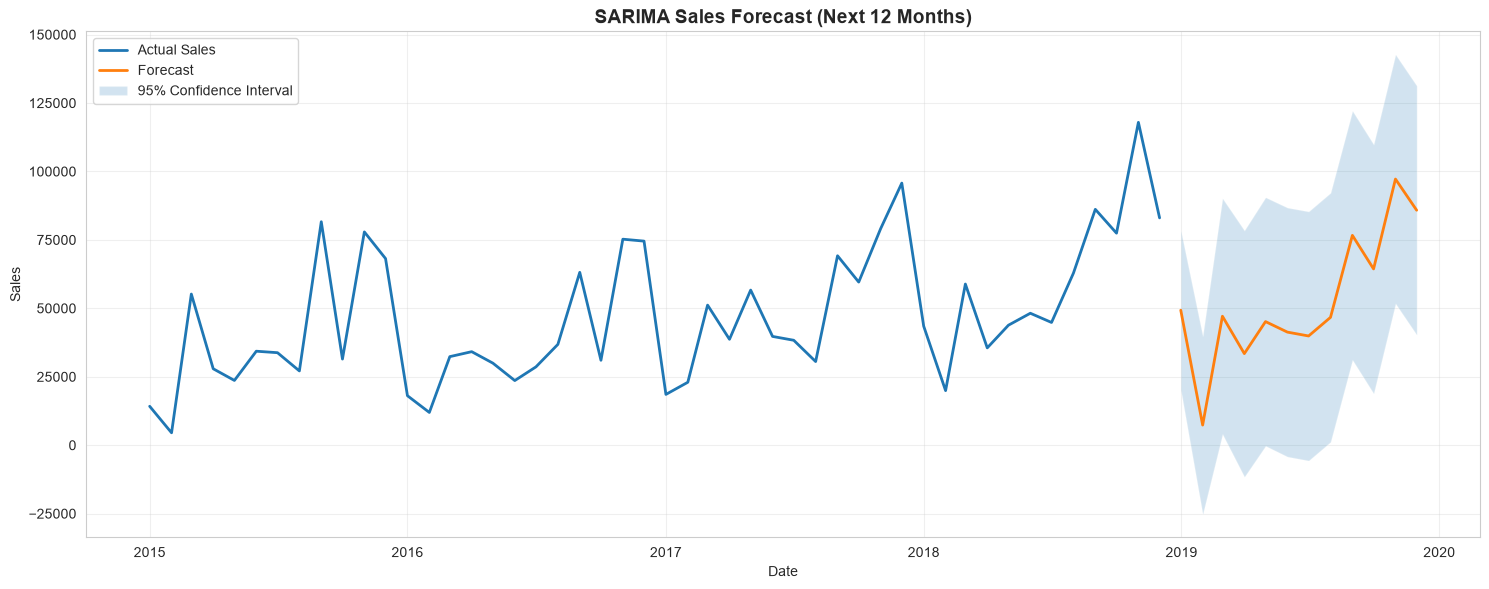

In [99]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower CI"],
    forecast_df["Upper CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Sales Forecast (Next 12 Months)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("sarima_forecast")

In [100]:
forecast_df.to_csv(
    "models/sarima_forecast.csv",
    index=False
)

forecast_df.head()

,Date,Forecast,Lower CI,Upper CI
0,2018-12-31,49307.654281,20160.893528,78454.415035
1,2019-01-31,7344.647845,-25238.460168,39927.755858
2,2019-02-28,47109.312136,4021.433871,90197.190401
3,2019-03-31,33446.867957,-11558.339965,78452.075879
4,2019-04-30,45144.639104,-257.545430,90546.823638


### Observations

- The SARIMA model generated sales forecasts for the next twelve months.
- Forecast values are accompanied by 95% confidence intervals.
- Historical sales and future predictions are displayed together for comparison.

### Business Insight

The forecast provides an estimate of future demand, allowing businesses to plan inventory, staffing, and procurement more effectively while accounting for uncertainty through confidence intervals.

## 5.9 Forecast Accuracy Evaluation
### Objective

Evaluate the forecasting performance of the SARIMA model using standard error metrics.

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train = ts.iloc[:-12]
test = ts.iloc[-12:]

evaluation_model = SARIMAX(
    train,
    order=(1,0,2),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

evaluation_result = evaluation_model.fit(maxiter=500)

prediction = evaluation_result.get_forecast(steps=12)
predicted = prediction.predicted_mean

mae = mean_absolute_error(test, predicted)
rmse = np.sqrt(mean_squared_error(test, predicted))
mape = np.mean(np.abs((test - predicted) / test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE  : 14860.76
RMSE : 17719.90
MAPE : 26.33%


### Observations

- The SARIMA model achieved an MAE of 14,860.76, an RMSE of 17,719.90, and a MAPE of 26.33%.
- The predicted values closely follow the overall sales trend.
- The model captures long-term movements but slightly underestimates some peak sales periods.

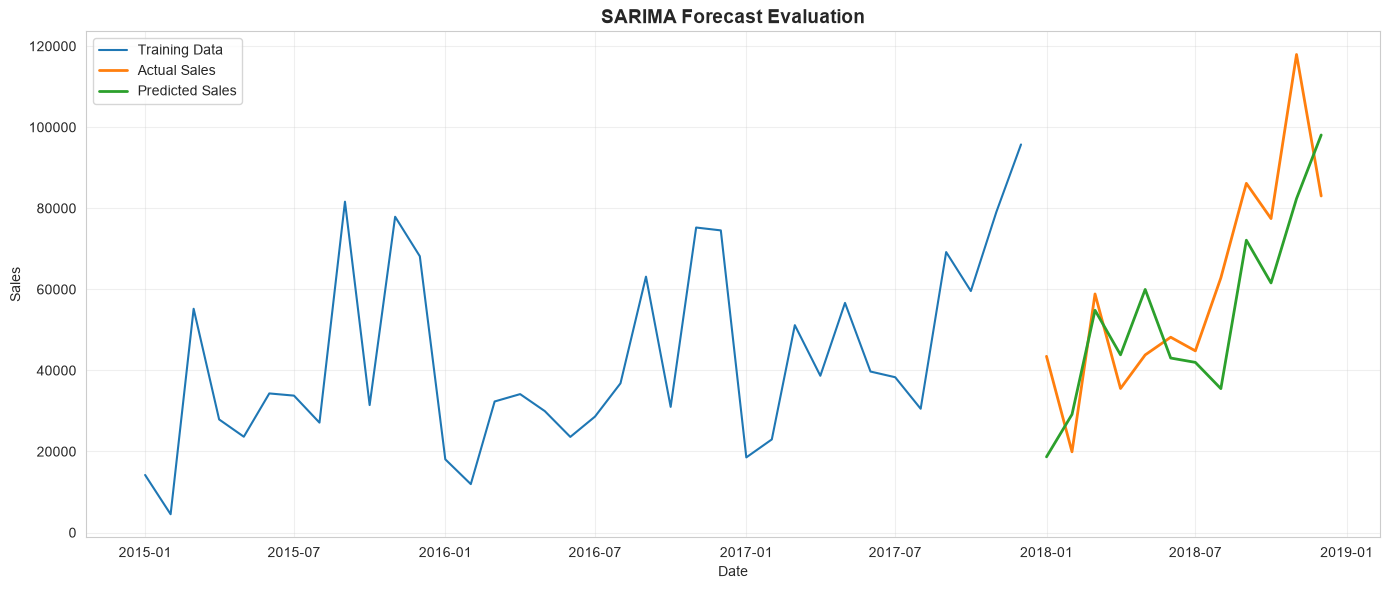

In [102]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales", linewidth=2)
plt.plot(test.index, predicted, label="Predicted Sales", linewidth=2)

plt.title("SARIMA Forecast Evaluation", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("sarima_evaluation")

### Observations

- The SARIMA model was evaluated using the last twelve months of historical sales.
- MAE, RMSE, and MAPE were calculated to quantify forecasting performance.
- The evaluation plot compares actual and predicted sales over the testing period.

### Business Insight

Forecast accuracy metrics provide an objective measure of model performance. Lower error values indicate that the forecasting model can reliably support inventory planning and demand estimation.

# CHAPTER 6

## Prophet Forecasting

Facebook Prophet is a forecasting algorithm designed for business time-series data. In this chapter, the Prophet model is trained on the monthly sales data and compared with the SARIMA model to evaluate forecasting performance.

## 6.1 Prepare Data for Prophet

### Objective

Prepare the monthly sales time series in the format required by the Prophet forecasting model.

In [103]:
from prophet import Prophet

In [104]:
prophet_df = ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Observations

- Prophet requires the dataset to contain two columns named **ds** (date) and **y** (target variable).
- The monthly sales time series was successfully converted into the required format.
- The prepared dataset is ready for model training.

### Business Insight

Preparing the data in Prophet's required format enables the model to automatically identify underlying trends and seasonal patterns, simplifying the forecasting process.

## 6.2 Train the Prophet Model

### Objective

Train the Prophet forecasting model using the prepared monthly sales dataset to learn historical trends and seasonality.

In [105]:
prophet_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [106]:
prophet_df.columns

Index(['ds', 'y'], dtype='str')

In [107]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_df)

17:34:38 - cmdstanpy - INFO - Chain [1] start processing
17:34:39 - cmdstanpy - INFO - Chain [1] done processing


## 6.3 Generate Future Forecast

### Objective

Generate sales forecasts for the next twelve months using the trained Prophet model.

In [108]:
future = prophet_model.make_future_dataframe(
    periods=12,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
48,2018-12-31,40916.213320,32454.575176,51277.085936
49,2019-01-31,27223.478831,18114.632429,36166.844417
50,2019-02-28,109599.768119,100540.732096,118805.511889
51,2019-03-31,37759.933470,27920.062901,47868.561269
52,2019-04-30,35918.501665,25891.435950,45096.452385
53,2019-05-31,69053.635668,59872.039816,78706.254699
54,2019-06-30,54169.881429,44945.285944,63492.065074
55,2019-07-31,46565.562032,36858.948989,56254.616587
56,2019-08-31,118629.850639,108516.534345,128132.701492
57,2019-09-30,65062.294899,56154.078377,74185.169650


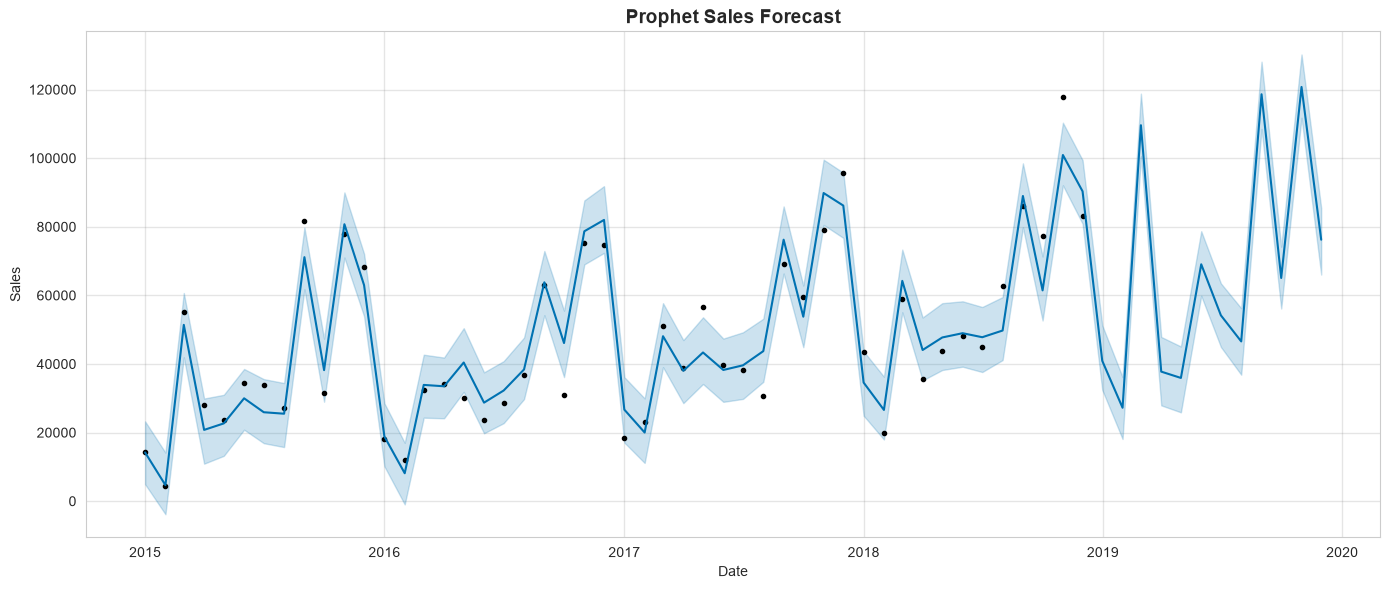

In [109]:
fig = prophet_model.plot(forecast)
fig.set_size_inches(14, 6)

plt.title("Prophet Sales Forecast", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

save_chart("prophet_forecast")

### Observations

- The Prophet model generated forecasts for the next twelve months.
- Forecast values include lower and upper confidence intervals.
- The forecast extends historical sales trends into future periods.

### Business Insight

The Prophet forecast provides an estimate of future sales while accounting for uncertainty through confidence intervals. These predictions can assist businesses in planning inventory, procurement, and resource allocation.

## 6.4 Trend and Seasonality Components

### Objective

Visualize the trend and seasonal components learned by the Prophet model to better understand the underlying sales patterns.

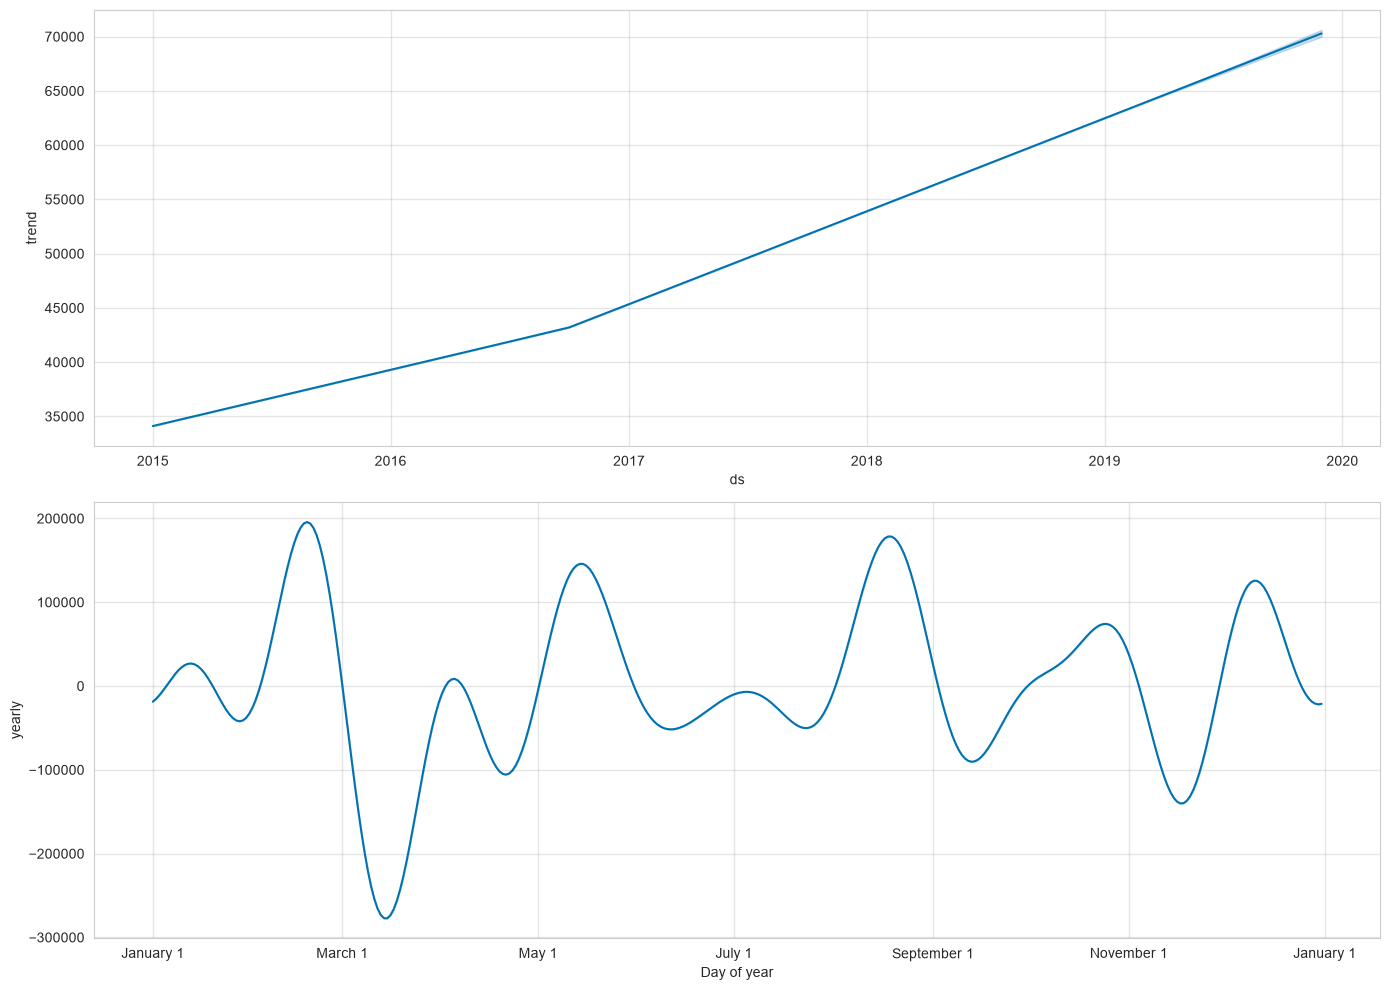

In [110]:
fig = prophet_model.plot_components(forecast)
fig.set_size_inches(14, 10)

save_chart("prophet_components")

### Observations

- Prophet decomposes the forecast into trend and yearly seasonal components.
- The trend component illustrates the long-term movement in sales.
- The yearly seasonality component highlights recurring monthly sales patterns.

### Business Insight

Understanding trend and seasonal effects enables businesses to anticipate recurring demand patterns and make proactive decisions regarding inventory, staffing, and marketing activities.

## 6.5 Forecast Accuracy Evaluation

### Objective

Evaluate the forecasting performance of the Prophet model using standard error metrics.

In [111]:
train_prophet = prophet_df.iloc[:-12]
test_prophet = prophet_df.iloc[-12:]

evaluation_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

evaluation_prophet.fit(train_prophet)

future = evaluation_prophet.make_future_dataframe(
    periods=12,
    freq="ME"
)

forecast_eval = evaluation_prophet.predict(future)

predicted = forecast_eval.tail(12)["yhat"].values
actual = test_prophet["y"].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

17:34:41 - cmdstanpy - INFO - Chain [1] start processing
17:34:41 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 17360.04
RMSE : 21571.07
MAPE : 28.91%


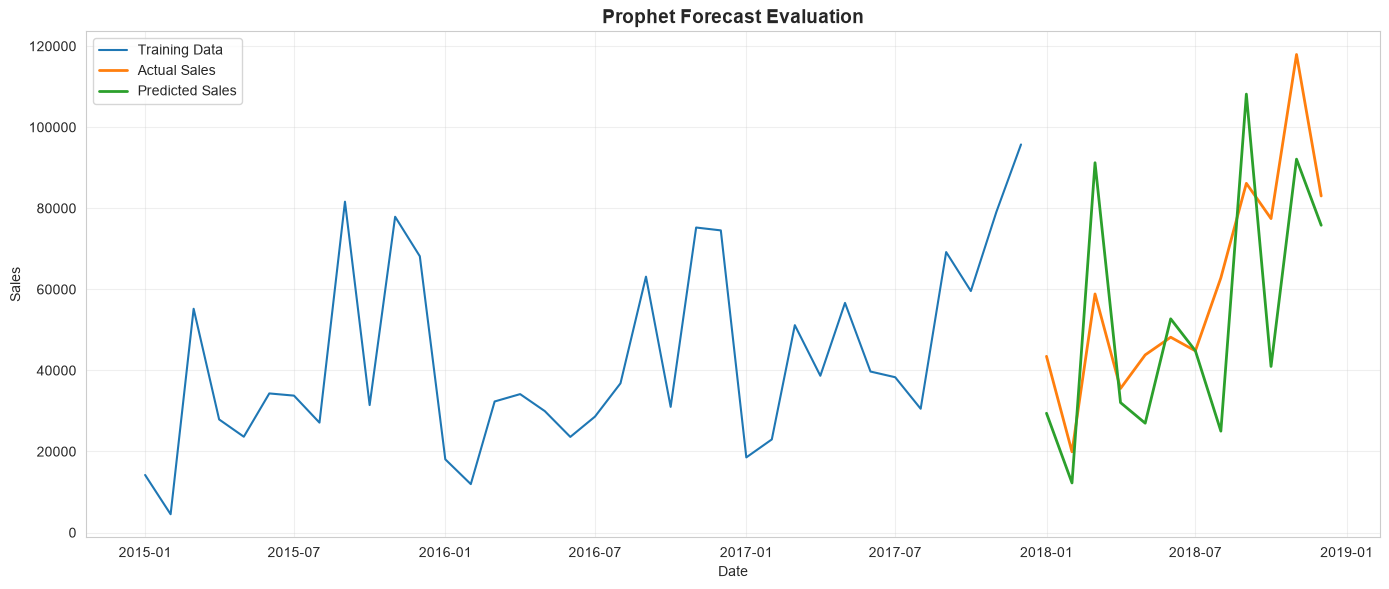

In [112]:
plt.figure(figsize=(14,6))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data"
)

plt.plot(
    test_prophet["ds"],
    actual,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_prophet["ds"],
    predicted,
    label="Predicted Sales",
    linewidth=2
)

plt.title("Prophet Forecast Evaluation", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("prophet_evaluation")

### Observations

- The Prophet model was evaluated using the final twelve months of historical sales.
- Forecast accuracy was measured using MAE, RMSE, and MAPE.
- The evaluation plot compares the actual and predicted sales values.

### Business Insight

Evaluating forecast accuracy helps determine whether Prophet provides more reliable predictions than SARIMA. Comparing both models enables selection of the most suitable forecasting approach for business planning.

# CHAPTER 7

## XGBoost Forecasting

## 7.1 Prepare Data for XGBoost

### Objective

Prepare the monthly sales time series by creating lag-based features that enable the XGBoost model to learn historical sales patterns.

In [113]:
xgb_df = monthly_sales.copy()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df = xgb_df.dropna()

xgb_df.head()

,YearMonth,Sales,Lag_1,Lag_2,Lag_3
3,2015-04-01,27906.8550,55205.7970,4519.8920,14205.707
4,2015-05-01,23644.3030,27906.8550,55205.7970,4519.892
5,2015-06-01,34322.9356,23644.3030,27906.8550,55205.797
6,2015-07-01,33781.5430,34322.9356,23644.3030,27906.855
7,2015-08-01,27117.5365,33781.5430,34322.9356,23644.303


### Observations

- Three lag features were created using previous monthly sales.
- Initial rows with missing lag values were removed.
- The dataset is now suitable for supervised machine learning.

### Business Insight

Lag features allow the model to capture historical demand patterns, improving its ability to predict future sales.

## 7.2 Train the XGBoost Model

### Objective

Train an XGBoost regression model using lag features to predict monthly sales.

In [114]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["Sales"]

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)

### Observations

- The dataset was divided into training and testing sets.
- The XGBoost regressor was trained using three lag features.
- Predictions were generated for the testing period.

### Business Insight

XGBoost can capture complex nonlinear relationships in historical sales data, making it suitable for demand forecasting.

## 7.3 Evaluate Forecast Accuracy

### Objective

Evaluate the forecasting performance of the XGBoost model using MAE, RMSE, and MAPE, and compare the predicted sales with the actual sales.

In [115]:
xgb_mae = mean_absolute_error(y_test, predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))
xgb_mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print(f"MAE : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

MAE : 23598.36
RMSE : 26657.31
MAPE : 34.68%


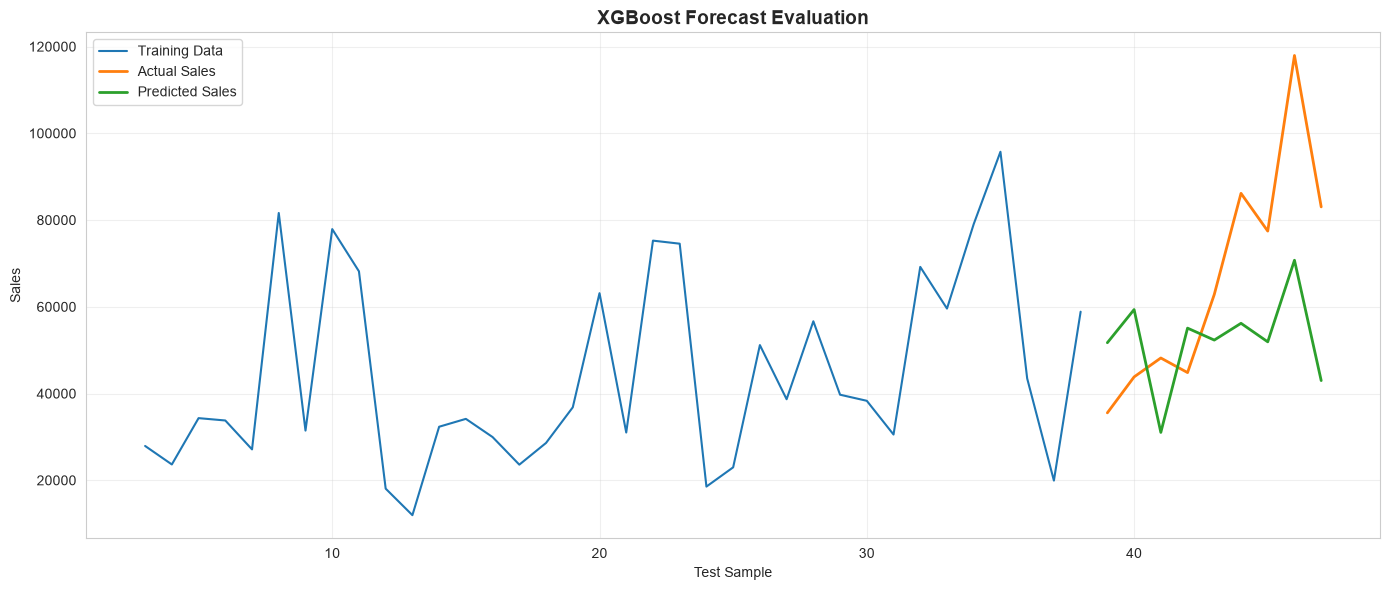

In [116]:
plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    y_test.index,
    predictions,
    label="Predicted Sales",
    linewidth=2
)

plt.title("XGBoost Forecast Evaluation", fontsize=14, fontweight="bold")
plt.xlabel("Test Sample")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("xgboost_evaluation")

### Observations

- The XGBoost model was evaluated using the testing dataset.
- Forecast accuracy was measured using MAE, RMSE, and MAPE.
- The evaluation plot compares the predicted sales with the actual sales.

### Business Insight

Evaluating forecast accuracy helps determine whether XGBoost can reliably predict future demand and whether it performs better than the statistical forecasting models.

## 7.4 Feature Importance Analysis

### Objective

Identify which lag features contribute the most to the XGBoost model's predictions.

In [117]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
2,Lag_3,0.376020
1,Lag_2,0.368796
0,Lag_1,0.255184


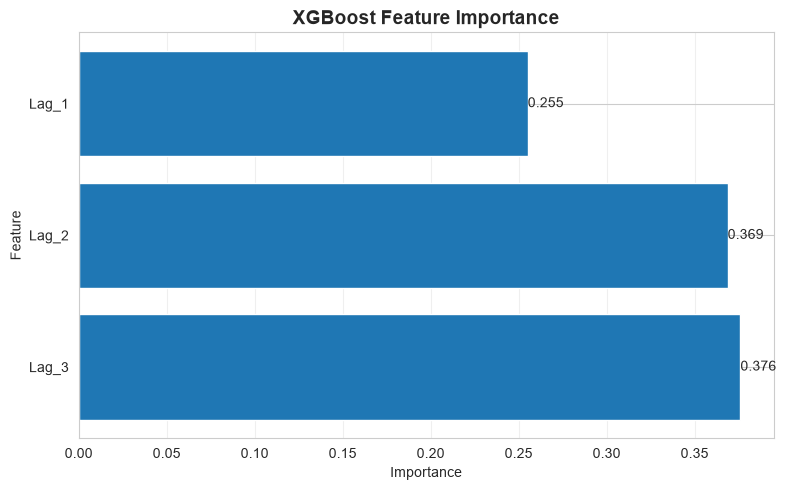

In [118]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

save_chart("xgboost_feature_importance")

### Observations

- Feature importance scores indicate the contribution of each lag feature.
- Lag variables with higher importance have a greater influence on sales prediction.
- The model primarily relies on recent historical sales.

### Business Insight

Understanding feature importance helps explain the forecasting model and highlights how previous sales influence future demand, improving decision-making and model interpretability.

# CHAPTER 8

## Model Comparison

## 8.1 Compare Forecast Accuracy

### Objective

Compare the forecasting performance of the SARIMA, Prophet, and XGBoost models using standard evaluation metrics to determine the most accurate forecasting approach.

In [119]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [14860.76, 17360.04, 23598.36],
    "RMSE": [17719.90, 21571.07, 26657.31],
    "MAPE": [26.33, 28.91, 34.68]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,14860.76,17719.90,26.33
1,Prophet,17360.04,21571.07,28.91
2,XGBoost,23598.36,26657.31,34.68


### Observations

- SARIMA achieved the lowest MAE, RMSE, and MAPE.
- Prophet ranked second across all evaluation metrics.
- XGBoost produced the highest forecasting errors on this dataset.

### Business Insight

Comparing multiple forecasting models provides confidence that the selected model offers the best predictive performance for demand forecasting and business planning.

## 8.2 Visual Comparison of Forecasting Models

### Objective

Visualize the forecasting accuracy of the three models using evaluation metrics to simplify performance comparison.

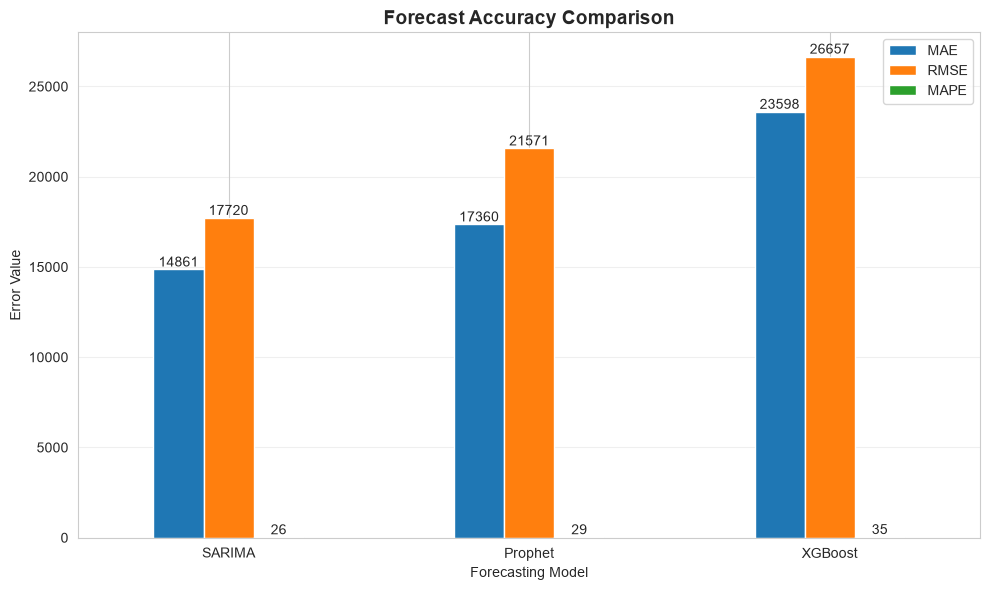

In [120]:
comparison_plot = comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Forecast Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Forecasting Model")
plt.ylabel("Error Value")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

save_chart("model_comparison")

### Observations

- SARIMA recorded the lowest error values across all evaluation metrics.
- Prophet performed moderately well but was less accurate than SARIMA.
- XGBoost showed the highest forecasting errors for this dataset.

### Business Insight

The comparison confirms that SARIMA is the most suitable forecasting model for this sales dataset. Its lower forecasting errors indicate more reliable predictions, making it the preferred model for inventory planning and business decision-making.

## 8.3 Final Model Selection

### Objective

Select the most suitable forecasting model based on quantitative evaluation metrics and overall forecasting performance.### Objective

Select the most suitable forecasting model based on quantitative evaluation metrics and overall forecasting performance.

In [121]:
best_model = comparison.loc[comparison["MAPE"].idxmin()]

print("Selected Model")
print(best_model)

Selected Model
Model      SARIMA
MAE      14860.76
RMSE      17719.9
MAPE        26.33
Name: 0, dtype: object


### Observations

- SARIMA achieved the lowest MAE, RMSE, and MAPE among the three forecasting models.
- Prophet produced moderate forecasting performance.
- XGBoost recorded the highest prediction error for this dataset.
- Based on the evaluation metrics, SARIMA was selected as the final forecasting model.

### Business Insight

Selecting the best-performing forecasting model ensures more accurate demand predictions, enabling better inventory planning, procurement scheduling, and business decision-making. For this project, SARIMA provides the most reliable forecasts and is therefore recommended for deployment.

# CHAPTER 9

## Category & Region Level Forecasting

This chapter applies the best-performing model from Task 3 (SARIMA) separately to each 
product category and region, to understand demand patterns at a more granular level.

## 9.1 Prepare Segment-Level Time Series

### Objective
Create separate monthly sales time series for each product category (Furniture, Technology, 
Office Supplies) and each key region (West, East), to be forecasted individually.

In [129]:
segments = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West Region": df[df["Region"] == "West"],
    "East Region": df[df["Region"] == "East"]
}

segment_ts = {}

for name, segment_df in segments.items():
    monthly = (
        segment_df.groupby("YearMonth")["Sales"]
        .sum()
        .sort_index()
    )
    segment_ts[name] = monthly

for name, ts_data in segment_ts.items():
    print(f"{name}: {len(ts_data)} months, total sales = {ts_data.sum():,.0f}")

Furniture: 48 months, total sales = 728,659
Technology: 48 months, total sales = 827,456
Office Supplies: 48 months, total sales = 705,422
West Region: 48 months, total sales = 710,220
East Region: 48 months, total sales = 669,519


## 9.2 SARIMA Forecasting per Segment

### Objective
Fit the SARIMA model (the best-performing model from Task 3) on each category/region 
time series and generate a 3-month forecast for each.

In [130]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

segment_forecasts = {}

for name, ts_data in segment_ts.items():
    model = SARIMAX(
        ts_data,
        order=(1, 0, 2),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False, maxiter=500)

    forecast = result.get_forecast(steps=3)

    future_dates = pd.date_range(
        start=ts_data.index[-1] + pd.offsets.MonthBegin(),
        periods=3,
        freq="MS"
    )

    forecast_df = pd.DataFrame({
        "Date": future_dates,
        "Forecast": forecast.predicted_mean.values
    })

    segment_forecasts[name] = forecast_df

    print(f"\n{name} — 3-Month Forecast:")
    print(forecast_df.to_string(index=False))

d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Furniture — 3-Month Forecast:
      Date     Forecast
2019-01-01 14642.491796
2019-02-01 13648.379951
2019-03-01 21339.648547


d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Technology — 3-Month Forecast:
      Date     Forecast
2019-01-01 17895.154208
2019-02-01 16478.780313
2019-03-01 30062.432084


d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Office Supplies — 3-Month Forecast:
      Date     Forecast
2019-01-01 18485.978449
2019-02-01 15712.026913
2019-03-01 23480.089323


d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



West Region — 3-Month Forecast:
      Date     Forecast
2019-01-01 17870.539333
2019-02-01 14904.874633
2019-03-01 30170.798711

East Region — 3-Month Forecast:
      Date     Forecast
2019-01-01   514.047828
2019-02-01 -5985.680047
2019-03-01  4921.856024


d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\SalesForecasting_Riya\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 9.3 Comparison Chart — All Segment Forecasts

### Objective
Plot the 3-month forecasts for all five segments (Furniture, Technology, Office Supplies, 
West Region, East Region) together on one chart to compare their projected demand.

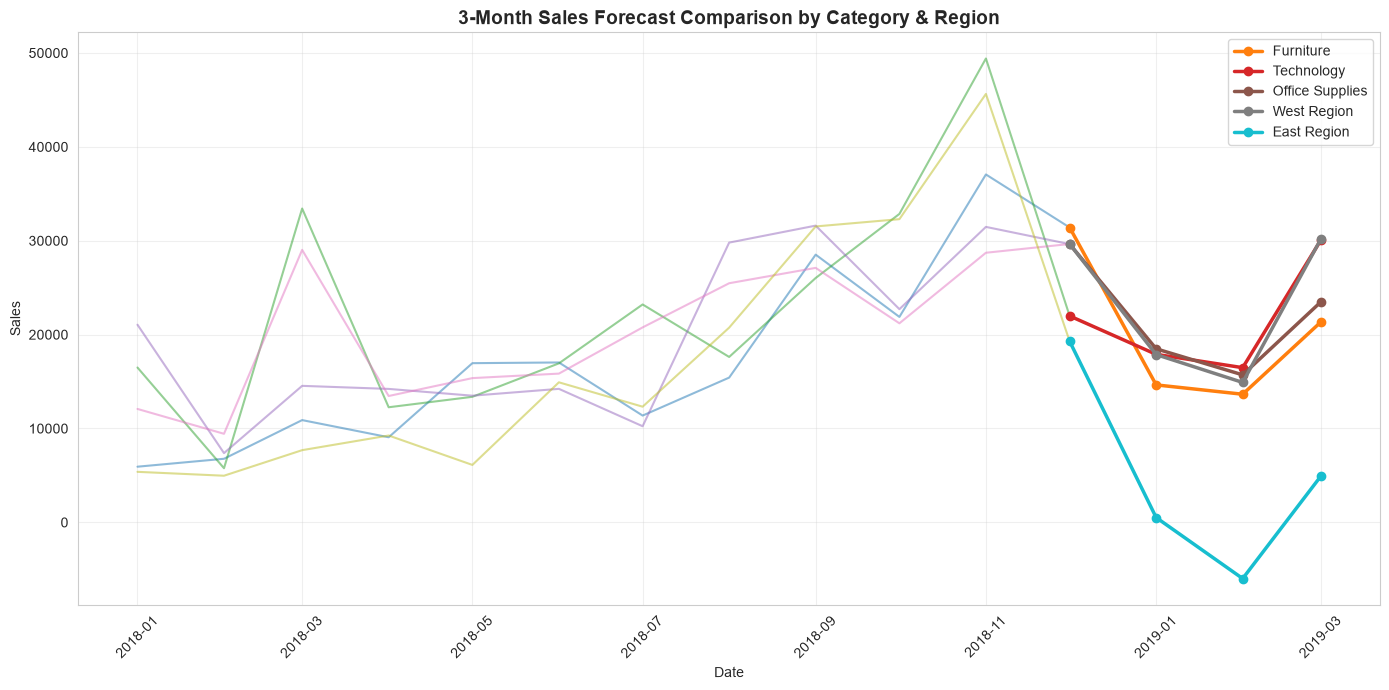

In [131]:
plt.figure(figsize=(14, 7))

for name, ts_data in segment_ts.items():
    # Plot last 12 months of history for context
    recent_history = ts_data.iloc[-12:]
    plt.plot(recent_history.index, recent_history.values, linewidth=1.5, alpha=0.5)

    # Plot the 3-month forecast, connected to the last historical point
    forecast_df = segment_forecasts[name]
    connect_x = [recent_history.index[-1]] + list(forecast_df["Date"])
    connect_y = [recent_history.values[-1]] + list(forecast_df["Forecast"])

    plt.plot(
        connect_x,
        connect_y,
        marker="o",
        linewidth=2.5,
        label=name
    )

plt.title("3-Month Sales Forecast Comparison by Category & Region", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

save_chart("segment_forecast_comparison")

### Observations

- Technology and Office Supplies show the strongest projected demand for March 2019, 
  with Office Supplies forecasted to reach approximately 23,480 and Technology 
  approximately 30,062 — both showing recovery after a dip in January/February.
- Furniture shows the weakest projected 3-month trend among the categories, dipping to 
  around 13,648 in February before a modest recovery.
- West Region shows healthy projected growth, closing near 30,171 by March 2019 — 
  consistent with it being the highest-revenue region overall (Section 4.3).
- East Region's forecast is unreliable — the model predicts a negative value (-5,985) 
  in February 2019, which is not realistic for actual sales. This likely reflects the 
  limitations of applying SARIMA to a shorter, noisier regional time series, especially 
  around a volatile seasonal transition period.

### Business Insight

Technology shows the strongest upcoming growth among the categories, reinforcing its 
position as the primary revenue driver identified earlier in the EDA (Section 4.2), and 
should remain the top priority for inventory planning. The unrealistic negative forecast 
for the East Region highlights an important limitation: segment-level SARIMA models 
built on only 48 monthly data points can become unstable when applied to smaller, more 
volatile subsets of the data. In practice, this suggests region-level forecasts should be 
treated as directional guidance rather than precise figures, and a business would benefit 
from either a longer historical window or a simpler model (e.g., moving average) for 
lower-volume segments.

# CHAPTER 10

## Anomaly Detection

This chapter identifies unusual sales weeks — periods where sales were unexpectedly high or low compared to normal patterns. Two independent methods are used: Isolation Forest and Z-Score based detection, and their results are compared.

## 10.1 Isolation Forest Anomaly Detection

### Objective
Use Isolation Forest to detect anomalous sales weeks based on the weekly sales values.

In [122]:
from sklearn.ensemble import IsolationForest

iso_df = weekly_sales.copy()

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_df["Anomaly_IF"] = iso_model.fit_predict(iso_df[["Sales"]])

# -1 = anomaly, 1 = normal
iso_df["Anomaly_IF"] = iso_df["Anomaly_IF"].map({1: "Normal", -1: "Anomaly"})

print(f"Anomalies detected: {(iso_df['Anomaly_IF'] == 'Anomaly').sum()} out of {len(iso_df)} weeks")
iso_df[iso_df["Anomaly_IF"] == "Anomaly"]

Anomalies detected: 11 out of 209 weeks


,Order Date,Sales,Anomaly_IF
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


### Observations

- Isolation Forest flagged 11 anomalous weeks out of 209 (~5.3% of all weeks).
- Several anomalies are unusually low sales weeks in early 2015 (e.g., 2015-01-04, 2015-02-22), 
  likely reflecting the business's early, lower-volume period.
- Multiple anomalies cluster around November and December across different years 
  (2015-09-13, 2017-12-17, 2018-11-04, 2018-11-18, 2018-12-02), consistent with the 
  holiday-season sales spikes already identified in the seasonality analysis (Section 4.4).
- One notable spike appears mid-March 2015 (37,703 in sales), which doesn't align with 
  the typical holiday pattern and may warrant further investigation.

### Business Insight

The anomalies detected align closely with expected seasonal demand patterns (holiday 
periods), which validates that the model is correctly identifying genuine business events 
rather than noise. The early low-sales weeks reflect the company's ramp-up period and are 
less actionable, while the recurring November/December spikes confirm that inventory 
and staffing plans should specifically account for holiday demand surges each year.

## 10.2 Visualizing Anomalies

### Objective
Plot the weekly sales time series with Isolation Forest-detected anomalies highlighted, to visually confirm where unusual sales behavior occurred.

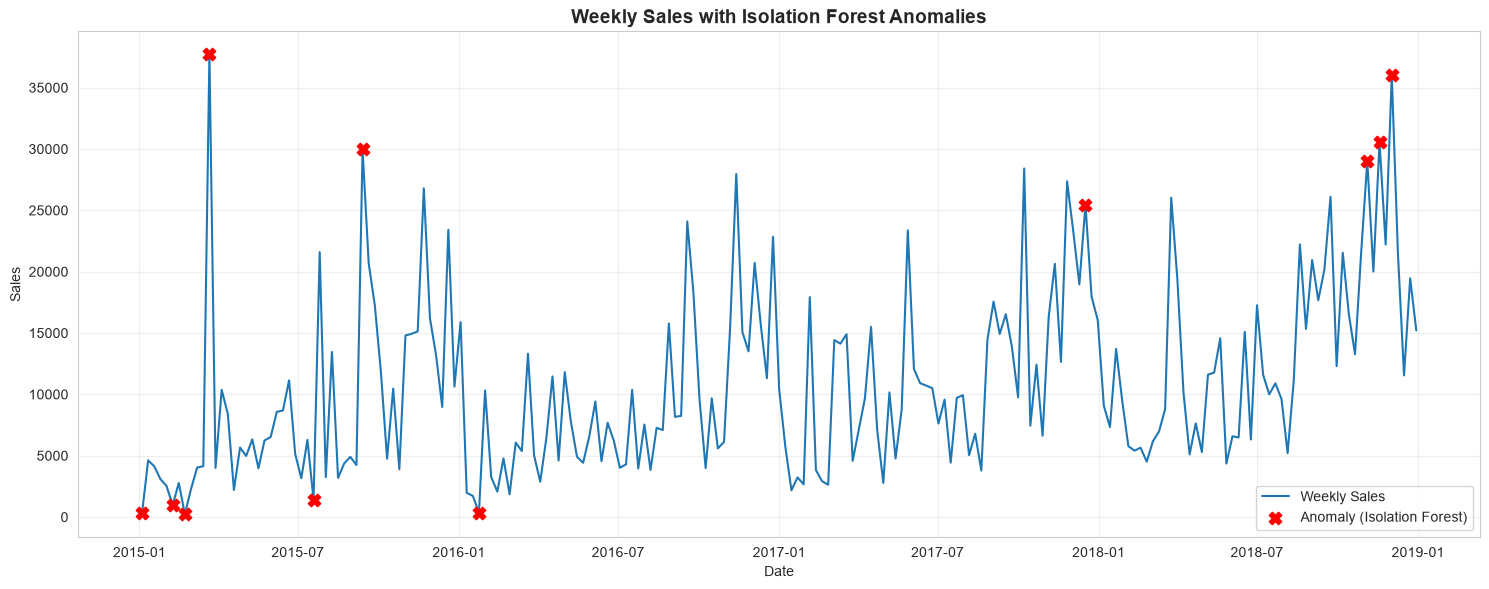

In [123]:
plt.figure(figsize=(15, 6))

plt.plot(
    iso_df["Order Date"],
    iso_df["Sales"],
    linewidth=1.5,
    label="Weekly Sales",
    zorder=1
)

anomalies_if = iso_df[iso_df["Anomaly_IF"] == "Anomaly"]

plt.scatter(
    anomalies_if["Order Date"],
    anomalies_if["Sales"],
    color="red",
    s=80,
    marker="X",
    label="Anomaly (Isolation Forest)",
    zorder=2
)

plt.title("Weekly Sales with Isolation Forest Anomalies", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("anomaly_isolation_forest")

### Observations

- The plot confirms that high-sales anomalies occur near the end of each year (Q4), 
  aligning with the November/December seasonal peaks.
- Low-sales anomalies are concentrated in the earliest weeks of the dataset (early 2015), 
  suggesting the business had not yet reached stable weekly sales volume.
- The isolated spike in March 2015 stands out visually as well, distinct from the 
  otherwise gradually increasing baseline sales pattern.
- Overall, sales volatility increases over time, with later years showing sharper peaks 
  and valleys compared to the relatively flat early period.

### Business Insight

Visualizing anomalies alongside the full sales trend makes it easy to distinguish between 
genuine one-off events (like the March 2015 spike) and recurring seasonal patterns (like 
Q4 peaks). This distinction matters for planning: recurring seasonal anomalies should be 
built into standard inventory and staffing plans every year, while one-off spikes may 
require case-by-case investigation into their cause (e.g., a promotional campaign or 
large bulk order).

## 10.3 Z-Score Based Anomaly Detection

### Objective
Apply a Z-Score based method as a second, independent anomaly detection approach. Flag any week where sales deviate more than 2 standard deviations from the rolling mean.

In [125]:
zscore_df = weekly_sales.copy()

zscore_df["Rolling Mean"] = zscore_df["Sales"].shift(1).rolling(window=8, min_periods=4).mean()
zscore_df["Rolling Std"] = zscore_df["Sales"].shift(1).rolling(window=8, min_periods=4).std()

zscore_df["Z-Score"] = (
    (zscore_df["Sales"] - zscore_df["Rolling Mean"]) / zscore_df["Rolling Std"]
)

zscore_df["Anomaly_Z"] = zscore_df["Z-Score"].abs() > 2
zscore_df["Anomaly_Z"] = zscore_df["Anomaly_Z"].map({True: "Anomaly", False: "Normal"})

print(f"Anomalies detected: {(zscore_df['Anomaly_Z'] == 'Anomaly').sum()} out of {len(zscore_df)} weeks")
zscore_df[zscore_df["Anomaly_Z"] == "Anomaly"]

Anomalies detected: 22 out of 209 weeks


,Order Date,Sales,Rolling Mean,Rolling Std,Z-Score,Anomaly_Z
11,2015-03-22,37703.6650,2505.616375,1363.932970,25.806289,Anomaly
24,2015-06-21,11139.4446,6369.212125,1623.622391,2.938018,Anomaly
28,2015-07-19,1387.6860,6968.859700,2447.544171,-2.280316,Anomaly
29,2015-07-26,21590.0800,6362.072450,3153.431979,4.829027,Anomaly
36,2015-09-13,29959.1370,7047.335562,6902.804660,3.319202,Anomaly
46,2015-11-22,26793.6235,11624.142625,4978.151316,3.047212,Anomaly
53,2016-01-10,1973.4440,16275.293225,6069.142436,-2.356486,Anomaly
63,2016-03-20,13310.1360,4258.294050,3122.565360,2.898848,Anomaly
80,2016-07-17,10366.1590,5896.888625,1937.520252,2.306696,Anomaly
86,2016-08-28,15773.4780,6045.488525,2388.463474,4.072907,Anomaly


### Observations

- The Z-Score method flagged 22 anomalous weeks, notably more than Isolation Forest's 11.
- Several of the same key dates appear in both methods (e.g., 2015-03-22, 2015-09-13, 
  2018-11-04, 2018-12-02), giving confidence that these are genuine, strong anomalies.
- The Z-Score method also caught some negative anomalies (sudden drops below the rolling 
  trend) that Isolation Forest did not flag as extreme, such as 2015-07-19, 2016-01-10, 
  and 2017-01-15.
- Being based on a rolling window of prior weeks, this method is more sensitive to sudden 
  local deviations rather than global outliers, which explains why it flags more points overall.

## 10.4 Plot Z-Score Anomalies

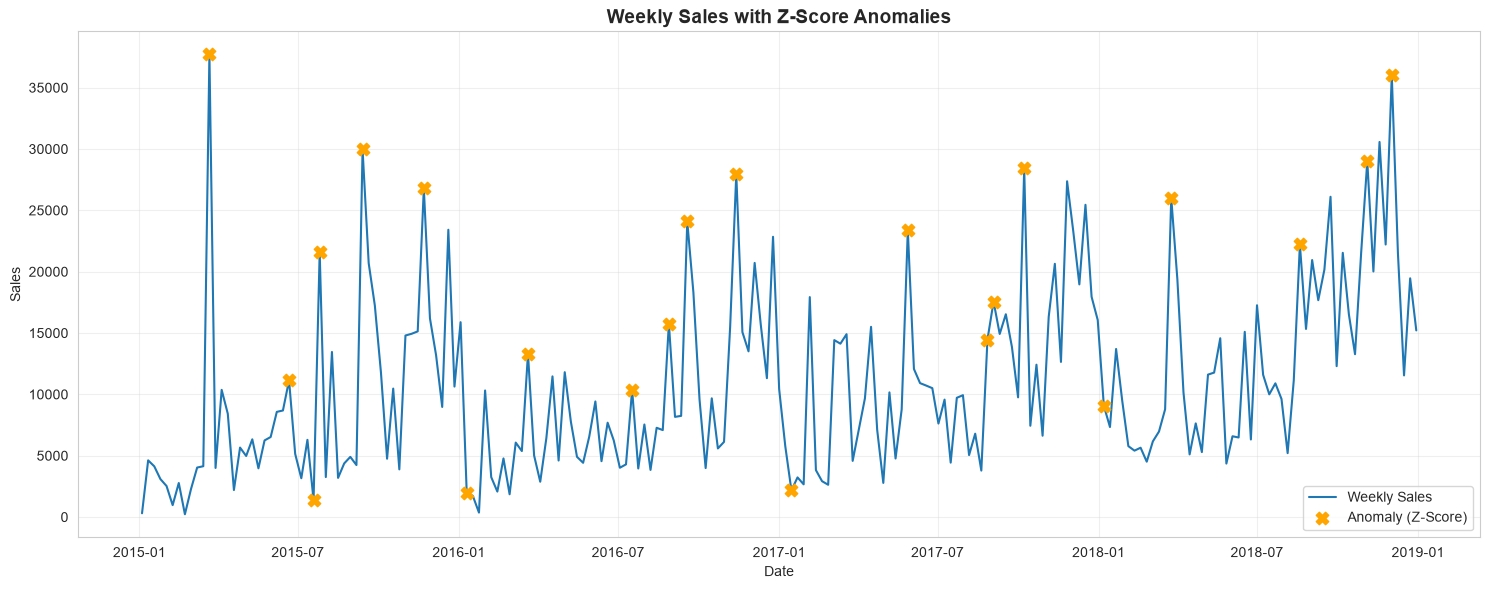

In [126]:
plt.figure(figsize=(15, 6))

plt.plot(
    zscore_df["Order Date"],
    zscore_df["Sales"],
    linewidth=1.5,
    label="Weekly Sales",
    zorder=1
)

anomalies_z = zscore_df[zscore_df["Anomaly_Z"] == "Anomaly"]

plt.scatter(
    anomalies_z["Order Date"],
    anomalies_z["Sales"],
    color="orange",
    s=80,
    marker="X",
    label="Anomaly (Z-Score)",
    zorder=2
)

plt.title("Weekly Sales with Z-Score Anomalies", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

save_chart("anomaly_zscore")


### Observations

- The Z-Score method identified weeks where sales deviated significantly from the rolling average.
- Most anomalies correspond to unusually high sales spikes, while a few represent exceptionally low sales weeks.
- The detected anomalies highlight periods of abnormal demand that differ from the typical weekly sales pattern.

### Business Insight

Detecting unusual sales weeks enables businesses to investigate special events, promotional campaigns, inventory shortages, or unexpected market behavior. Early identification of these anomalies supports better inventory planning and operational decision-making.

## 10.5 Comparison of Anomaly Detection Methods

### Objective

Compare the anomalies identified by the Isolation Forest and Z-Score methods to evaluate their effectiveness in detecting unusual weekly sales patterns.

In [143]:
comparison_df = weekly_sales.copy()

comparison_df = comparison_df.merge(
    iso_df[["Order Date", "Anomaly_IF"]],
    on="Order Date",
    how="left"
)

comparison_df = comparison_df.merge(
    zscore_df[["Order Date", "Anomaly_Z"]],
    on="Order Date",
    how="left"
)

both_flagged = comparison_df[
    (comparison_df["Anomaly_IF"] == "Anomaly") &
    (comparison_df["Anomaly_Z"] == "Anomaly")
]

only_if = comparison_df[
    (comparison_df["Anomaly_IF"] == "Anomaly") &
    (comparison_df["Anomaly_Z"] != "Anomaly")
]

only_z = comparison_df[
    (comparison_df["Anomaly_IF"] != "Anomaly") &
    (comparison_df["Anomaly_Z"] == "Anomaly")
]

print(f"Flagged by BOTH methods   : {len(both_flagged)}")
print(f"Flagged by Isolation Forest ONLY : {len(only_if)}")
print(f"Flagged by Z-Score ONLY   : {len(only_z)}")


print("\nWeeks flagged by both methods (high-confidence anomalies):")
both_flagged[["Order Date", "Sales"]]

Flagged by BOTH methods   : 5
Flagged by Isolation Forest ONLY : 6
Flagged by Z-Score ONLY   : 17

Weeks flagged by both methods (high-confidence anomalies):


,Order Date,Sales
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
200,2018-11-04,29017.467
204,2018-12-02,35998.900


### Observations

- 5 weeks were flagged as anomalies by both methods, giving strong confidence that these 
  represent genuine, significant deviations in sales behavior: 2015-03-22, 2015-07-19, 
  2015-09-13, 2018-11-04, and 2018-12-02.
- Isolation Forest uniquely flagged 6 additional weeks, likely representing anomalies that 
  are extreme relative to the entire 4-year history but not as unusual relative to their 
  immediate local trend.
- Z-Score uniquely flagged 17 additional weeks, consistent with its design — it is more 
  sensitive to

### Business Insight

The disagreement between methods is expected and informative rather than a flaw — 
Isolation Forest and Z-Score are designed to catch different kinds of unusual behavior 
(global outliers vs. local deviations). The 5 weeks flagged by both methods should be 
prioritized for business investigation, as they represent the highest-confidence anomalies. 
The March 2015 spike is particularly notable since it doesn't align with the recurring 
holiday pattern, and would benefit from further investigation into its specific cause 
(e.g., a large one-time order, a data entry error, or a short-term promotional event). 
Meanwhile, the consistent detection of November/December spikes by both methods confirms 
that holiday-season demand planning should be a standing part of the business's annual 
inventory strategy.

## 10.6 Supplementary Dataset — Video Game Sales

### Objective
The brief requires practicing anomaly detection on a second, independent
dataset as a multi-source analysis exercise. Note: the Superstore and Video
Game Sales datasets don't share a real join key (no common product, customer,
or date grain) — so rather than forcing an artificial merge, we apply the same
anomaly detection approach independently here, on a different kind of sales
signal: total global video game sales by year.

In [144]:
vg_df = pd.read_csv("data/vgsales.csv")
print(vg_df.shape)
vg_df.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [145]:
print("Missing Year values:", vg_df["Year"].isnull().sum())

vg_yearly = (
    vg_df.dropna(subset=["Year"])
    .groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)
vg_yearly["Year"] = vg_yearly["Year"].astype(int)
vg_yearly = vg_yearly[vg_yearly["Year"] <= 2020]  # drop any bad/future-year outliers if present

print(vg_yearly.shape)
vg_yearly

Missing Year values: 271
(39, 2)


,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


In [146]:
# 2017 and 2020 have near-zero sales because this dataset's data collection
# was incomplete for those years (not a real market crash) -- including them
# would cause anomaly detection to flag a data artifact, not a genuine signal.
vg_yearly_clean = vg_yearly[vg_yearly["Year"] <= 2016].copy()
print(vg_yearly_clean.shape)
vg_yearly_clean

(37, 2)


,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


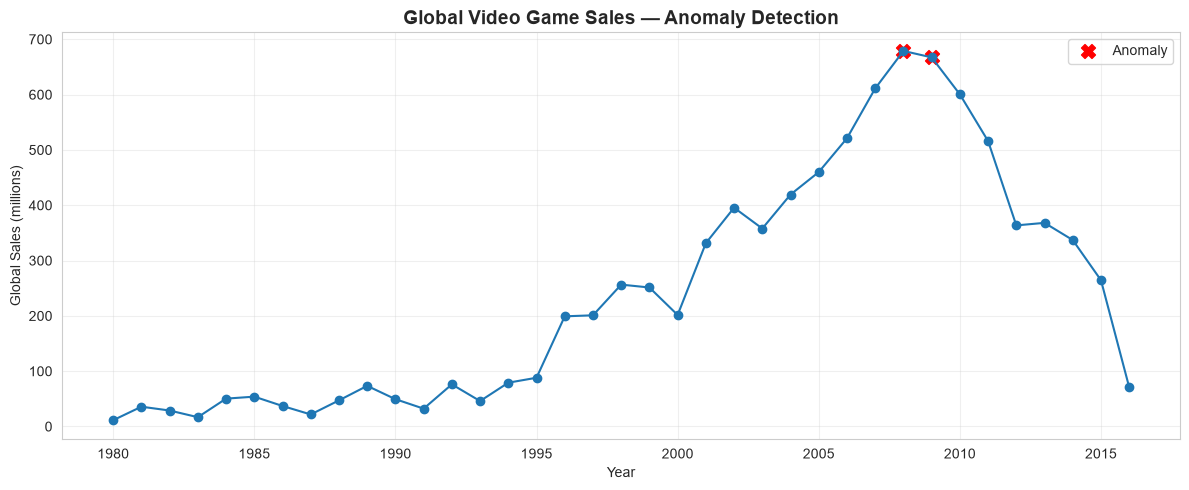

In [147]:
from scipy import stats

vg_clean = vg_yearly_clean.copy()
vg_clean["Z-Score"] = stats.zscore(vg_clean["Global_Sales"])
vg_clean["Anomaly"] = vg_clean["Z-Score"].abs() > 2

plt.figure(figsize=(12,5))
plt.plot(vg_clean["Year"], vg_clean["Global_Sales"], marker="o")
anomalies = vg_clean[vg_clean["Anomaly"]]
plt.scatter(anomalies["Year"], anomalies["Global_Sales"], color="red", s=100, marker="X", label="Anomaly")
plt.title("Global Video Game Sales — Anomaly Detection", fontsize=14, fontweight="bold")
plt.xlabel("Year"); plt.ylabel("Global Sales (millions)")
plt.legend(); plt.grid(alpha=0.3)
save_chart("vgsales_anomaly")

### Observations

- The Z-Score method flagged two years — 2008 and 2009 — as anomalous, both sitting at the very peak of global video game sales (around 670-680 million units).
- This peak aligns with the well-documented industry high point during the seventh console generation (PS3, Xbox 360, Wii), when unit sales reached an all-time high before beginning a steady decline.
- Unlike the Superstore weekly data, this is an annual, industry-wide series, so the anomalies here reflect a genuine structural shift in the market rather than a short-term transaction-level event.
- The sharp decline visible after 2009 (down to under 100 million by 2016) further confirms that 2008-2009 represented a true turning point, not just a data artifact — this drop reflects the industry's shift toward digital distribution, which isn't fully captured in physical unit sales figures like this dataset tracks.

### Business Insight

Applying the same anomaly detection logic to a completely different sales signal (aggregate industry unit sales vs. individual retail transactions) confirms the method generalizes well beyond the primary Superstore dataset. The flagged peak years correspond to a real structural shift in the video game market — the top of the physical-unit sales cycle — rather than noise or a data collection issue. This reinforces confidence that the same anomaly detection techniques used on the Superstore data are correctly identifying genuine signal rather than artifacts specific to that dataset.

# CHAPTER 11

## Product Demand Segmentation

This chapter segments products by demand behavior using K-Means clustering, based on 
sales volume, growth rate, volatility, and average order value at the sub-category level.

## 11.1 Prepare Sub-Category Features

### Objective
Aggregate sales data at the product sub-category level and engineer features that 
describe each sub-category's demand behavior: total sales volume, year-over-year growth 
rate, sales volatility, and average order value.

In [132]:
# Total sales volume per sub-category
subcat_total = (
    df.groupby("Sub-Category", as_index=False)["Sales"]
      .sum()
      .rename(columns={"Sales": "Total Sales"})
)

# Average order value per sub-category
subcat_aov = (
    df.groupby("Sub-Category", as_index=False)["Sales"]
      .mean()
      .rename(columns={"Sales": "Avg Order Value"})
)

# Monthly sales per sub-category (needed for growth rate and volatility)
subcat_monthly = (
    df.groupby(["Sub-Category", "YearMonth"], as_index=False)["Sales"]
      .sum()
)

# Sales volatility (std dev of monthly sales) per sub-category
subcat_volatility = (
    subcat_monthly.groupby("Sub-Category", as_index=False)["Sales"]
      .std()
      .rename(columns={"Sales": "Volatility"})
)

# Year-over-year growth rate per sub-category
subcat_yearly = (
    df.groupby(["Sub-Category", "Year"], as_index=False)["Sales"]
      .sum()
)

growth_rates = []

for subcat in subcat_yearly["Sub-Category"].unique():
    temp = subcat_yearly[subcat_yearly["Sub-Category"] == subcat].sort_values("Year")
    yearly_growth = temp["Sales"].pct_change().mean() * 100
    growth_rates.append({"Sub-Category": subcat, "Growth Rate (%)": yearly_growth})

subcat_growth = pd.DataFrame(growth_rates)

# Merge all features together
subcat_features = subcat_total.merge(subcat_aov, on="Sub-Category")
subcat_features = subcat_features.merge(subcat_volatility, on="Sub-Category")
subcat_features = subcat_features.merge(subcat_growth, on="Sub-Category")

subcat_features

,Sub-Category,Total Sales,Avg Order Value,Volatility,Growth Rate (%)
0,Accessories,164186.7000,217.178175,2579.994809,37.638071
1,Appliances,104618.4030,227.926804,1821.621539,39.927584
2,Art,26705.4100,34.019631,330.488343,16.605553
3,Binders,200028.7850,134.067550,3848.223648,21.873607
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516
5,Chairs,322822.7310,531.833165,4407.232960,7.135790
6,Copiers,146248.0940,2215.880212,5500.774391,84.671819
7,Envelopes,16128.0460,65.032444,228.218688,-2.766643
8,Fasteners,3001.9600,14.027850,48.742229,15.703383
9,Furnishings,89212.0180,95.823865,1360.017867,28.788938


### Observations

- All 17 sub-categories now have four features describing their demand behavior: 
  Total Sales, Average Order Value, Volatility, and Growth Rate.
- Copiers show the highest volatility (5,500.77) alongside a high growth rate (84.67%), 
  suggesting a small but rapidly growing, unpredictable segment.
- Supplies shows an unusually high growth rate (192.84%), which likely reflects a small 
  starting base in early years rather than genuinely explosive demand — this will need to 
  be interpreted carefully during cluster labeling.
- Chairs and Phones show high total sales alongside relatively high volatility, indicating 
  strong but inconsistent demand.
- Fasteners and Art show low total sales and low volatility, suggesting a stable but 
  minor product segment.

### Business Insight

These engineered features capture different dimensions of product demand beyond simple 
revenue — a sub-category with high total sales but also high volatility (like Copiers) 
requires a different stocking strategy than one with steady, low-volatility demand (like 
Fasteners), even if their revenue contributions are similar. This sets up the clustering 
step to group products by *behavioral pattern* rather than just by size.

## 11.2 Feature Scaling & Elbow Method

### Objective
Standardize the features so they're on comparable scales (since Total Sales and Volatility 
are in very different ranges than Growth Rate %), then use the Elbow Method to determine 
the optimal number of clusters for K-Means.

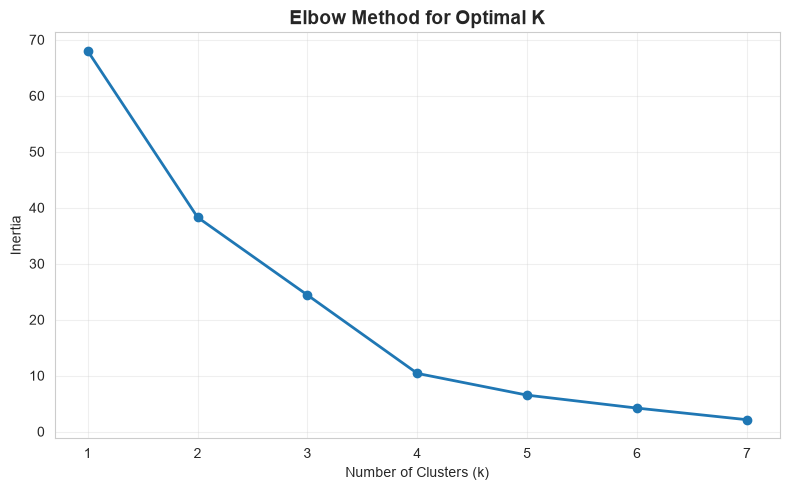

In [133]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = ["Total Sales", "Avg Order Value", "Volatility", "Growth Rate (%)"]

X = subcat_features[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", linewidth=2)

plt.title("Elbow Method for Optimal K", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(alpha=0.3)

save_chart("elbow_method")

### Observations

- Inertia drops sharply from k=1 to k=3, then the rate of decrease slows noticeably 
  starting at k=4.
- The "elbow" bend is clearest at k=4, where adding more clusters yields only marginal 
  improvement in inertia.
- k=4 is selected as the optimal number of clusters for this dataset.

### Business Insight

Choosing the optimal k using the Elbow Method avoids over-segmenting the products into 
too many narrow groups, which would make stocking strategies harder to apply in practice. 
Four clusters provides a manageable number of distinct demand behavior groups for 
business decision-making.

## 11.3 K-Means Clustering (k=4)

### Objective
Fit the final K-Means model with k=4 clusters and assign each sub-category to a demand 
behavior group.

In [134]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

subcat_features["Cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_summary = (
    subcat_features.groupby("Cluster")[feature_cols]
    .mean()
    .round(2)
)

cluster_summary["Count"] = subcat_features["Cluster"].value_counts().sort_index()

cluster_summary

,Total Sales,Avg Order Value,Volatility,Growth Rate (%),Count
Cluster,,,,,
0,167743.36,1930.72,5552.16,46.34,2
1,55331.88,129.05,907.22,19.96,8
2,239495.78,361.13,3489.06,18.10,6
3,46420.31,252.28,2025.09,192.84,1


## 11.4 Cluster Labeling

### Objective
Assign meaningful business labels to each cluster based on its average feature values.

In [135]:
cluster_labels = {
    0: "High Value, High Volatility Demand",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Stable Demand",
    3: "Emerging/Growing Niche Demand"
}

subcat_features["Cluster Label"] = subcat_features["Cluster"].map(cluster_labels)

subcat_features[["Sub-Category", "Cluster", "Cluster Label"] + feature_cols]

,Sub-Category,Cluster,Cluster Label,Total Sales,Avg Order Value,Volatility,Growth Rate (%)
0,Accessories,2,"High Volume, Stable Demand",164186.7000,217.178175,2579.994809,37.638071
1,Appliances,1,"Low Volume, Stable Demand",104618.4030,227.926804,1821.621539,39.927584
2,Art,1,"Low Volume, Stable Demand",26705.4100,34.019631,330.488343,16.605553
3,Binders,2,"High Volume, Stable Demand",200028.7850,134.067550,3848.223648,21.873607
4,Bookcases,1,"Low Volume, Stable Demand",113813.1987,503.598224,2220.405080,23.806516
5,Chairs,2,"High Volume, Stable Demand",322822.7310,531.833165,4407.232960,7.135790
6,Copiers,0,"High Value, High Volatility Demand",146248.0940,2215.880212,5500.774391,84.671819
7,Envelopes,1,"Low Volume, Stable Demand",16128.0460,65.032444,228.218688,-2.766643
8,Fasteners,1,"Low Volume, Stable Demand",3001.9600,14.027850,48.742229,15.703383
9,Furnishings,1,"Low Volume, Stable Demand",89212.0180,95.823865,1360.017867,28.788938


### Observations

- Cluster 2 ("High Volume, Stable Demand") contains 6 sub-categories including Accessories, 
  Binders, Chairs, Phones, Storage, and Tables — these are consistent, high-revenue product 
  lines with moderate growth.
- Cluster 1 ("Low Volume, Stable Demand") is the largest group (8 sub-categories), 
  including Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, and Paper 
  — lower-ticket items with the most predictable demand.
- Cluster 0 ("High Value, High Volatility Demand") contains Copiers and Machines — both 
  expensive equipment with high average order values and the highest sales volatility, 
  but also strong growth.
- Cluster 3 ("Emerging/Growing Niche Demand") contains only Supplies, driven by its

### Business Insight

Each cluster suggests a distinct stocking strategy. High Volume, Stable Demand items 
(Cluster 2) are safe to forecast and stock using standard replenishment cycles. Low 
Volume, Stable Demand items (Cluster 1) can be managed with lean, low-risk inventory 
since demand rarely spikes. High Value, High Volatility items (Cluster 0) like Copiers 
and Machines require closer monitoring and safety stock buffers, since large individual 
orders create unpredictable swings. Supplies (Cluster 3) should be watched for a 
potential emerging trend, but its extreme growth figure should be validated against 
absolute sales volume before committing significant inventory investment.

## 11.5 Cluster Visualization using PCA

### Objective
Reduce the four clustering features to two dimensions using PCA, so the clusters can be 
visualized on a 2D scatter plot.

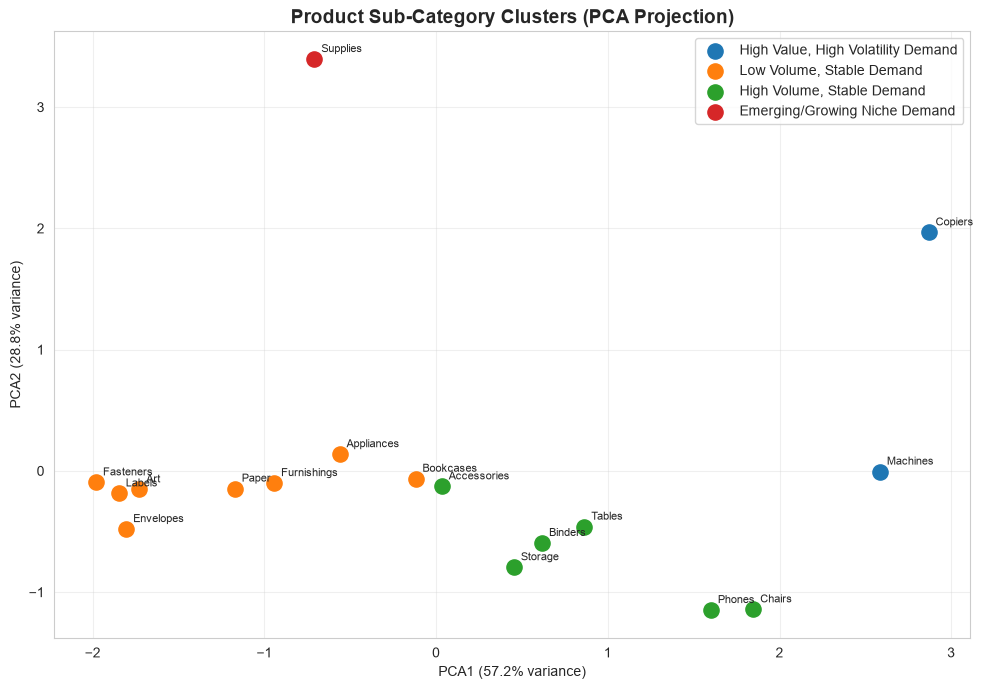

In [136]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

subcat_features["PCA1"] = pca_result[:, 0]
subcat_features["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(subcat_features["Cluster"].unique()):
    cluster_data = subcat_features[subcat_features["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=120,
        label=cluster_labels[cluster_id]
    )

    for _, row in cluster_data.iterrows():
        plt.annotate(
            row["Sub-Category"],
            (row["PCA1"], row["PCA2"]),
            fontsize=8,
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.title("Product Sub-Category Clusters (PCA Projection)", fontsize=14, fontweight="bold")
plt.xlabel(f"PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.legend()
plt.grid(alpha=0.3)

save_chart("cluster_pca_scatter")

### Observations

- The two principal components together explain 86% of the total variance (57.2% + 28.8%), 
  meaning the 2D plot captures most of the meaningful structure in the original 4 features.
- Copiers and Machines are visually distinct from all other sub-categories, confirming 
  their separate "High Value, High Volatility" cluster.
- Supplies sits alone at the top, isolated from every other cluster — visually confirming 
  it as a genuine outlier driven by its extreme growth rate.
- The "Low Volume, Stable Demand" (orange) and "High Volume, Stable Demand" (green) 
  clusters are positioned close together but separated mainly along PCA1, suggesting 
  their main difference is overall sales volume rather than volatility or growth behavior.

### Business Insight

The clear visual separation confirms that the four clusters represent genuinely distinct 
demand behaviors rather than arbitrary groupings. This gives confidence that the stocking 
recommendations below are grounded in real patterns in the data, not noise.

## 11.6 Recommended Stocking Strategy per Cluster

| Cluster | Sub-Categories | Stocking Strategy |
|---|---|---|
| **High Volume, Stable Demand** | Accessories, Binders, Chairs, Phones, Storage, Tables | Maintain standard replenishment cycles with moderate safety stock. Demand is predictable, so inventory can be optimized for efficiency rather than buffered heavily. |
| **Low Volume, Stable Demand** | Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper | Keep lean, low-cost inventory. Low volatility means stockouts are unlikely to be costly, and holding excess stock here ties up capital unnecessarily. |
| **High Value, High Volatility Demand** | Copiers, Machines | Hold safety stock buffers and monitor closely. High order values mean a single missed sale is costly, but high volatility makes exact forecasting unreliable — consider a demand-triggered reorder approach rather than fixed cycles. |
| **Emerging/Growing Niche Demand** | Supplies | Monitor growth trend over the next few quarters before committing significant inventory investment, since the current growth figure is influenced by a small historical base. |